In [2]:
#Đỗ Ngọc Lâm - B22DCCN476
data = pd.read_csv("data_4.2.csv")
data.head(100)

,age,gender,height_cm,weight_kg,mod_act_hr_per_week,vig_act_hr_per_week
0,37.0,Male,154.94,86.182550,32.0,NaN
1,37.0,Female,165.10,77.110703,30.0,2.0
2,28.0,Male,180.34,86.182550,20.0,30.0
3,26.0,Female,165.10,63.502932,10.0,15.0
4,47.0,Male,170.18,70.306817,18.0,10.0
...,...,...,...,...,...,...
95,50.0,Female,160.02,54.431084,30.0,NaN
96,22.0,Male,182.88,81.646627,50.0,NaN
97,53.0,Male,182.88,154.221406,4.0,0.0
98,50.0,Female,160.02,82.553811,2.0,0.0


Phân phối nhãn:
label
overweight     2998
normal         2242
underweight     589
Name: count, dtype: int64


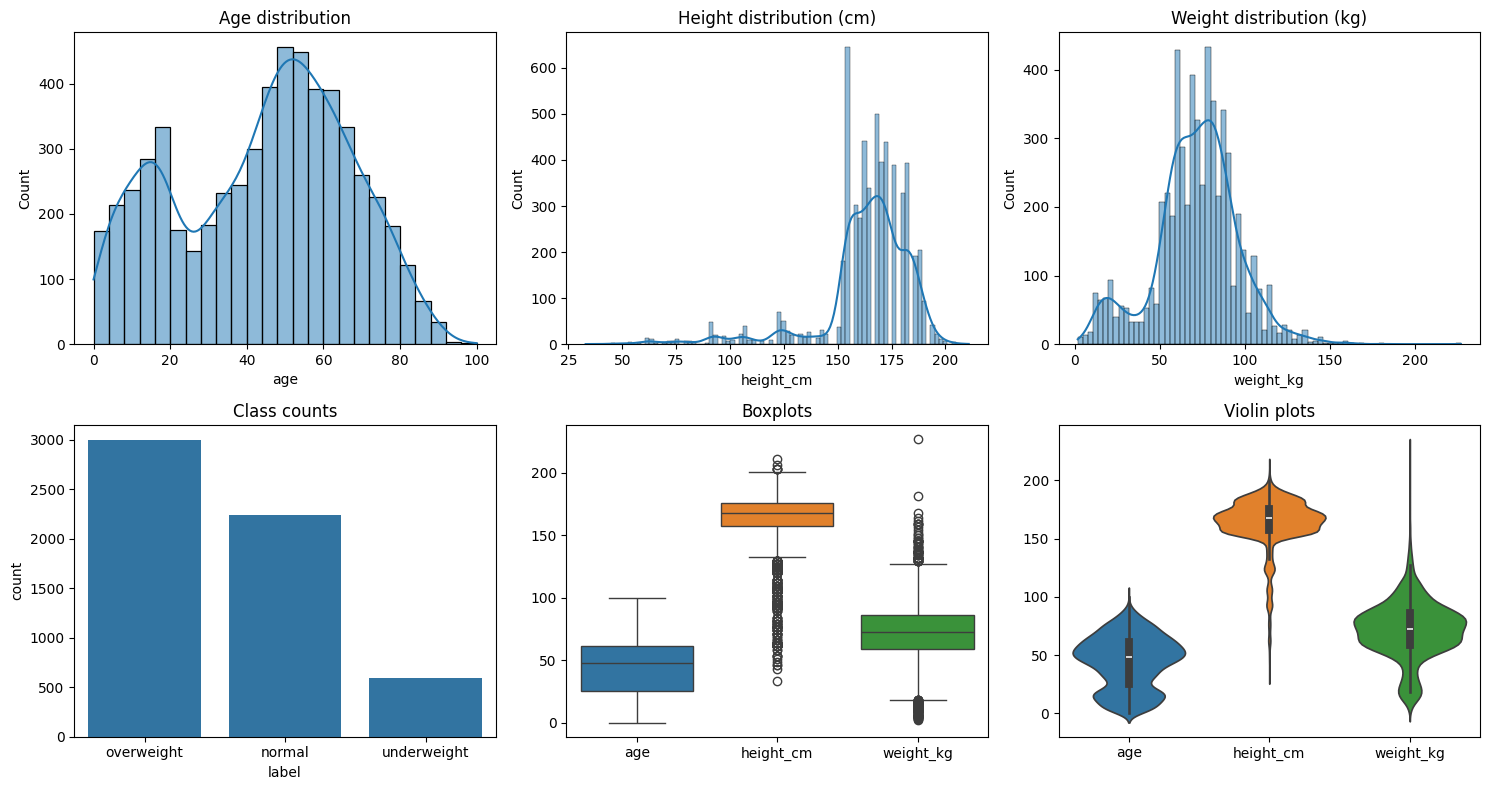

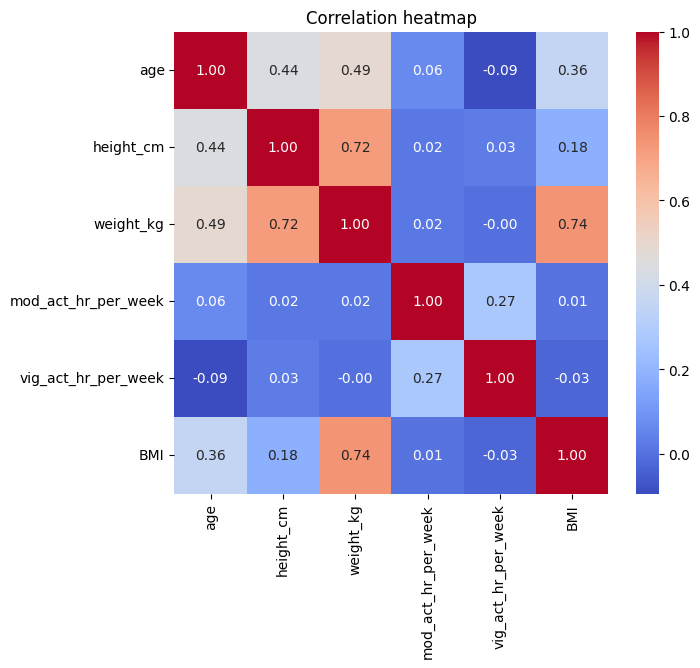

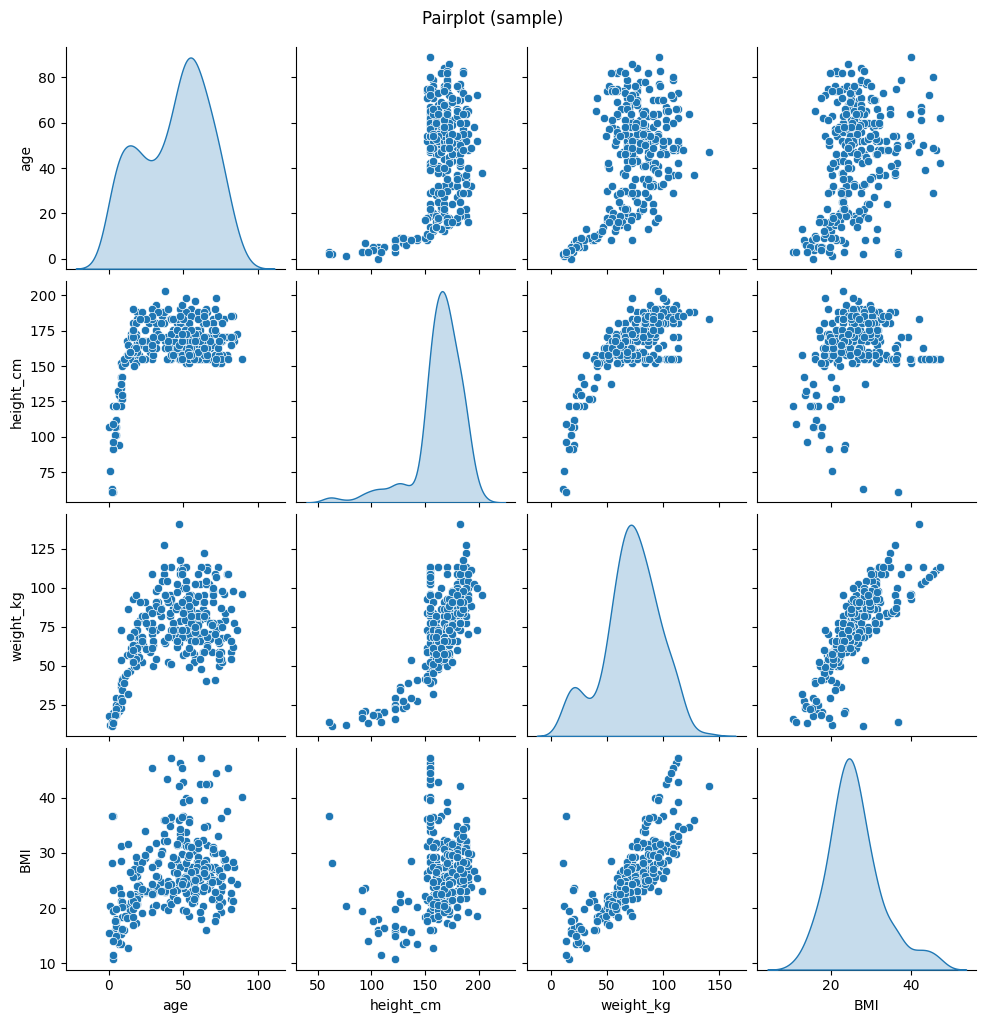


[KQ 5 mô hình ML cơ bản]
          model       acc       mae       mse      rmse
4  RandomForest  0.956261  0.044597  0.046312  0.215203
0        LogReg  0.949400  0.052316  0.055746  0.236106
1       SVM-RBF  0.941681  0.063465  0.073756  0.271581
3  DecisionTree  0.935678  0.065180  0.066895  0.258641
2           KNN  0.887650  0.114923  0.120069  0.346509


<Figure size 480x450 with 0 Axes>

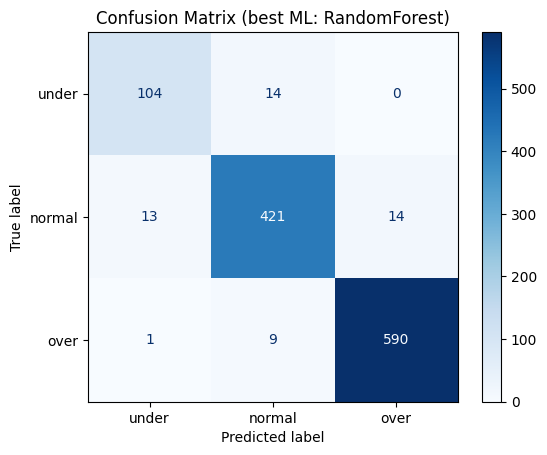


[KQ mô hình DL (CNN/RNN/LSTM)]
  model       acc       mae       mse      rmse
1   RNN  0.981990  0.018010  0.018010  0.134202
0   CNN  0.935678  0.066895  0.072041  0.268405
2  LSTM  0.668096  0.345626  0.373070  0.610795

[BẢNG SO SÁNH TỔNG HỢP]
          model       acc       mae       mse      rmse type
5           RNN  0.981990  0.018010  0.018010  0.134202   DL
0  RandomForest  0.956261  0.044597  0.046312  0.215203   ML
1        LogReg  0.949400  0.052316  0.055746  0.236106   ML
2       SVM-RBF  0.941681  0.063465  0.073756  0.271581   ML
6           CNN  0.935678  0.066895  0.072041  0.268405   DL
3  DecisionTree  0.935678  0.065180  0.066895  0.258641   ML
4           KNN  0.887650  0.114923  0.120069  0.346509   ML
7          LSTM  0.668096  0.345626  0.373070  0.610795   DL


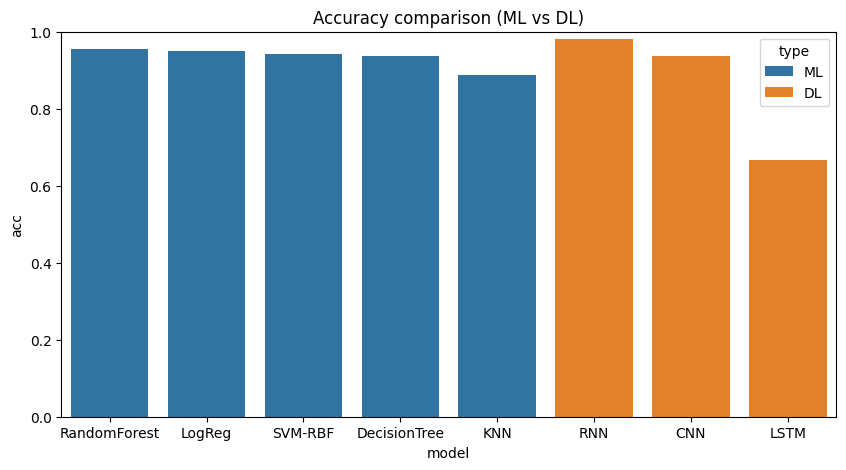

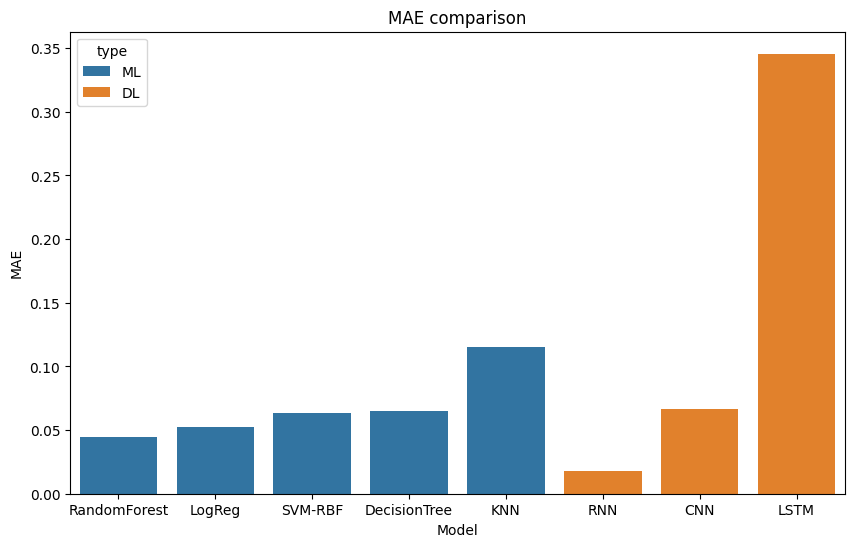

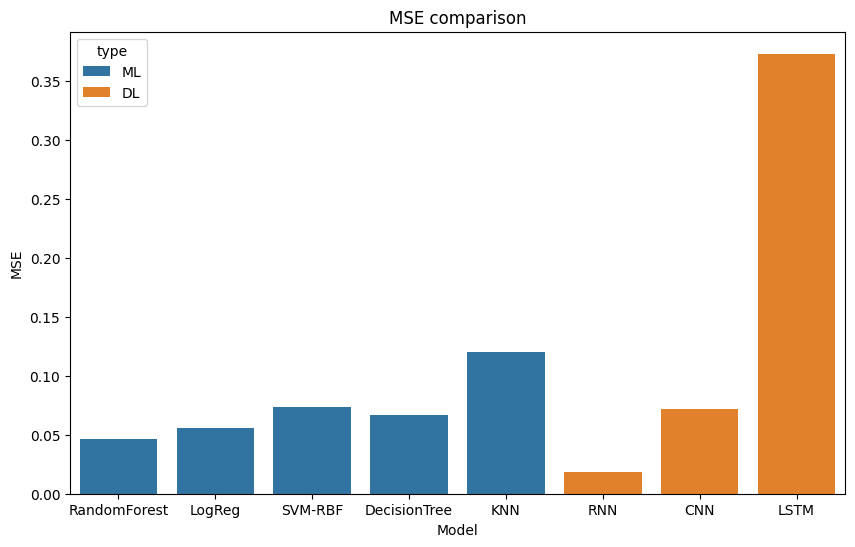

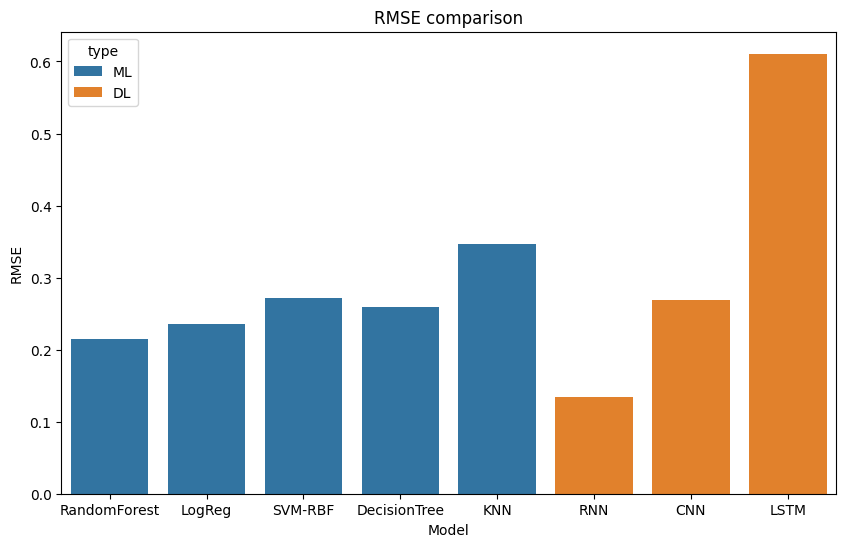

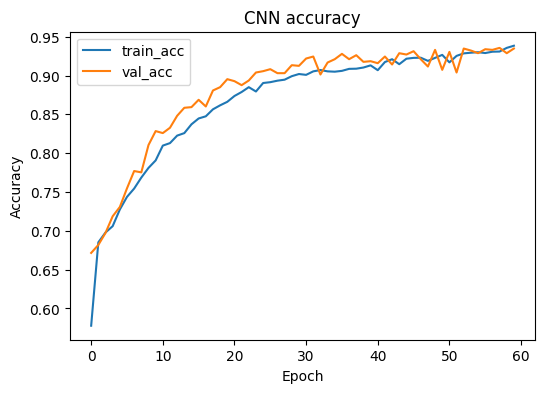

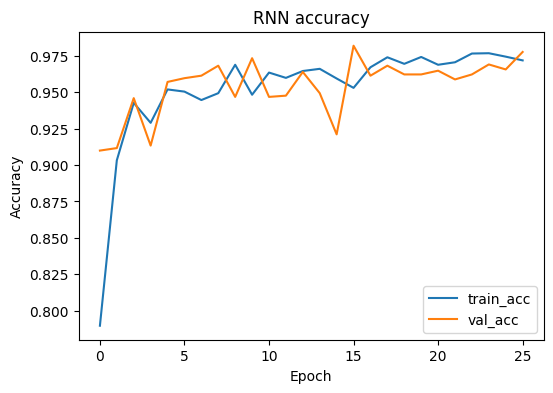

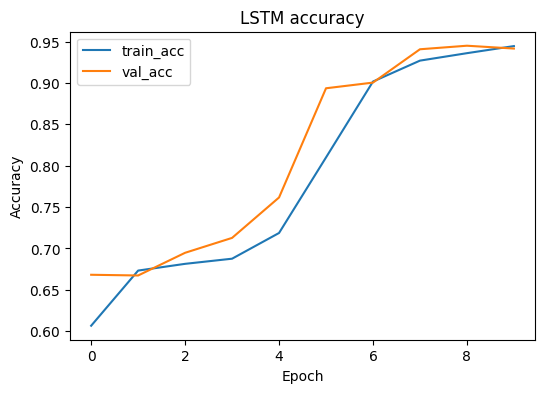


[DEPLOY] Best model: DL - RNN | acc=0.9820


Nhập giới tính (Male/Female):  Female
Nhập tuổi:  18
Nhập chiều cao (cm):  163
Nhập cân nặng (kg):  57
Giờ hoạt động mức vừa/tuần (mặc định 0):  2
Giờ hoạt động mức mạnh/tuần (mặc định 0):  1



[KẾT QUẢ DỰ ĐOÁN & TƯ VẤN]
{
  "input": {
    "gender": "Female",
    "age": 18,
    "height_cm": 163.0,
    "weight_kg": 57.0,
    "mod_act_hr_per_week": 2.0,
    "vig_act_hr_per_week": 1.0
  },
  "BMI": 21.5,
  "rule_label": "normal",
  "model_label": "normal",
  "advice": [
    "Duy trì chế độ ăn cân bằng, nhiều rau củ quả (≥400 g/ngày).",
    "Hoạt động thể lực: ≥150 phút/tuần mức vừa hoặc ≥75 phút/tuần mức mạnh; tập tăng cơ ≥2 ngày/tuần.",
    "Hạn chế đồ uống có đường và thực phẩm siêu chế biến.",
    "Duy trì thói quen ngủ đủ giấc, quản lý stress."
  ]
}


In [3]:
#Đỗ Ngọc Lâm - B22DCCN476
# =========================
# (b)→(g) ALL-IN-ONE cho data_4.2.csv (cột: age, gender, height_cm, weight_kg, mod_act_hr_per_week, vig_act_hr_per_week)
# =========================
import os, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, ConfusionMatrixDisplay

# 5 mô hình ML cơ bản
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------
# ĐƯỜNG DẪN
# -------------------------
DATA_DIR = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"  # đổi nếu cần
DATA_PATH = os.path.join(DATA_DIR, "data_4.2.csv")
KB_PATH   = os.path.join(DATA_DIR, "kb_healthGuide.json")
assert os.path.exists(DATA_PATH), "Chưa thấy data_4.2.csv — hãy đặt file đúng đường dẫn!"

# -------------------------
# (b) Show the distribution
# -------------------------
df = pd.read_csv(DATA_PATH)

# Điền NA hoạt động thể lực (nếu có) bằng 0
for col in ["mod_act_hr_per_week", "vig_act_hr_per_week"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Tính BMI và nhãn (gộp obesity vào 'overweight' theo đề)
def bmi_from_hw(h_cm, w_kg):
    return w_kg / ((h_cm/100.0)**2)

df["BMI"] = bmi_from_hw(df["height_cm"].astype(float), df["weight_kg"].astype(float))

def bmi_label(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    else:
        return "overweight"  # gộp >=25 (bao gồm obese) vào overweight
df["label"] = df["BMI"].apply(bmi_label)

print("Phân phối nhãn:")
print(df["label"].value_counts())

# Hiển thị phân phối (>=5 loại biểu đồ)
plt.figure(figsize=(15,8))
plt.subplot(2,3,1); sns.histplot(df["age"], kde=True); plt.title("Age distribution")
plt.subplot(2,3,2); sns.histplot(df["height_cm"], kde=True); plt.title("Height distribution (cm)")
plt.subplot(2,3,3); sns.histplot(df["weight_kg"], kde=True); plt.title("Weight distribution (kg)")
plt.subplot(2,3,4); sns.countplot(data=df, x="label"); plt.title("Class counts")
plt.subplot(2,3,5); sns.boxplot(data=df[["age","height_cm","weight_kg"]]); plt.title("Boxplots")
plt.subplot(2,3,6); sns.violinplot(data=df[["age","height_cm","weight_kg"]]); plt.title("Violin plots")
plt.tight_layout()
plt.show()

# Heatmap tương quan
plt.figure(figsize=(7,6))
corr_cols = ["age","height_cm","weight_kg","mod_act_hr_per_week","vig_act_hr_per_week","BMI"]
corr_cols = [c for c in corr_cols if c in df.columns]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

# Pairplot (một loại hình nữa)
sns.pairplot(df[["age","height_cm","weight_kg","BMI"]].sample(min(300,len(df))), diag_kind="kde")
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()


# --------------------------------------------------------
# Chuẩn bị dữ liệu cho học máy
# --------------------------------------------------------
# Dùng đúng các cột có trong dataset của bạn
feature_cols = ["gender","age","height_cm","weight_kg","mod_act_hr_per_week","vig_act_hr_per_week"]
feature_cols = [c for c in feature_cols if c in df.columns]  # đề phòng thiếu

X = df[feature_cols].copy()
y = df["label"].map({"underweight":0, "normal":1, "overweight":2}).astype(int)  # encode 3 lớp thành 0/1/2

# Tách cat/num theo cột thực tế
cat_cols = [c for c in ["gender"] if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=7)

preprocess = ColumnTransformer([
    ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("scaler", StandardScaler(), num_cols)
])

# --------------------------------------------------------
# (c) 5 mô hình ML cơ bản
# --------------------------------------------------------
ml_models = {
    "LogReg": LogisticRegression(max_iter=300),
    "SVM-RBF": SVC(kernel="rbf", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, random_state=7),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=7)
}

ml_results, ml_pipelines = [], {}

for name, model in ml_models.items():
    pipe = Pipeline([("prep", preprocess), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = math.sqrt(mse)
    ml_results.append({"model": name, "acc": acc, "mae": mae, "mse": mse, "rmse": rmse})
    ml_pipelines[name] = pipe

ml_df = pd.DataFrame(ml_results).sort_values("acc", ascending=False)
print("\n[KQ 5 mô hình ML cơ bản]")
print(ml_df)

# Confusion matrix cho mô hình ML tốt nhất
best_ml_name = ml_df.iloc[0]["model"]
best_ml = ml_pipelines[best_ml_name]
y_pred_best_ml = best_ml.predict(X_val)

plt.figure(figsize=(4.8,4.5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best_ml, display_labels=["under","normal","over"], cmap="Blues")
plt.title(f"Confusion Matrix (best ML: {best_ml_name})")
plt.show()


# --------------------------------------------------------
# (d) 3 mô hình DL: CNN, RNN, LSTM — mỗi mô hình 5 tầng
#  Dữ liệu tabular -> preprocess -> mảng -> reshape (samples, steps=n_features, channels=1)
# --------------------------------------------------------
X_train_t = preprocess.fit_transform(X_train)
X_val_t   = preprocess.transform(X_val)

n_features = X_train_t.shape[1]
num_classes = 3

# chuyển sang dense nếu là sparse
def to_dense(a):
    return np.asarray(a.todense() if hasattr(a, "todense") else a)

X_train_seq = to_dense(X_train_t).reshape(-1, n_features, 1)
X_val_seq   = to_dense(X_val_t).reshape(-1, n_features, 1)

y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)

def build_cnn(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="cnn_1d")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_rnn(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.SimpleRNN(64, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="rnn_simple")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="lstm_1")
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

cnn  = build_cnn((n_features,1), num_classes)
rnn  = build_rnn((n_features,1), num_classes)
lstm = build_lstm((n_features,1), num_classes)

early = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy")

hist_cnn  = cnn.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                    epochs=60, batch_size=64, verbose=0, callbacks=[early])
hist_rnn  = rnn.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                    epochs=60, batch_size=64, verbose=0, callbacks=[early])
hist_lstm = lstm.fit(X_train_seq, y_train_oh, validation_data=(X_val_seq, y_val_oh),
                     epochs=60, batch_size=64, verbose=0, callbacks=[early])

def eval_dl(model, name):
    y_pred_prob = model.predict(X_val_seq, verbose=0)
    y_pred = y_pred_prob.argmax(axis=1)
    acc = accuracy_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = math.sqrt(mse)
    return {"model": name, "acc": acc, "mae": mae, "mse": mse, "rmse": rmse}

dl_results = [eval_dl(m, nm) for m, nm in [(cnn,"CNN"), (rnn,"RNN"), (lstm,"LSTM")]]
dl_df = pd.DataFrame(dl_results).sort_values("acc", ascending=False)
print("\n[KQ mô hình DL (CNN/RNN/LSTM)]")
print(dl_df)

# So sánh tất cả mô hình (c & d)
all_df = pd.concat([ml_df.assign(type="ML"), dl_df.assign(type="DL")], ignore_index=True)
print("\n[BẢNG SO SÁNH TỔNG HỢP]")
print(all_df.sort_values(["acc","type"], ascending=[False, True]))

# (e) Vẽ biểu đồ so sánh metrics
plt.figure(figsize=(10,5))
sns.barplot(data=all_df, x="model", y="acc", hue="type")
plt.title("Accuracy comparison (ML vs DL)")
plt.ylim(0,1); plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="mae", hue="type")
plt.title("MAE comparison"); plt.ylabel("MAE"); plt.xlabel("Model"); plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="mse", hue="type")
plt.title("MSE comparison"); plt.ylabel("MSE"); plt.xlabel("Model"); plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=all_df, x="model", y="rmse", hue="type")
plt.title("RMSE comparison"); plt.ylabel("RMSE"); plt.xlabel("Model"); plt.show()

# Learning curves
def plot_history(h, title):
    plt.figure(figsize=(6,4))
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.title(title); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()
plot_history(hist_cnn, "CNN accuracy")
plot_history(hist_rnn, "RNN accuracy")
plot_history(hist_lstm, "LSTM accuracy")

# --------------------------------------------------------
# (g) Deploy best model + Health Guide (KB JSON)
# --------------------------------------------------------

# 1) Chọn mô hình tốt nhất theo accuracy (ưu tiên DL, nếu bằng thì lấy DL)
best_row = all_df.sort_values(["acc","type"], ascending=[False, True]).iloc[0]
best_name = best_row["model"]
best_type = best_row["type"]

if best_type == "ML":
    best_model = ml_pipelines[best_name]
    use_dl = False
else:
    m = {"CNN": cnn, "RNN": rnn, "LSTM": lstm}
    best_model = m[best_name]
    use_dl = True

print(f"\n[DEPLOY] Best model: {best_type} - {best_name} | acc={best_row['acc']:.4f}")

# 2) Knowledge Base: nếu chưa có file, tạo với nội dung chuẩn (WHO/CDC)
DEFAULT_KB = {
    "bmi_categories": {
        "underweight": "BMI < 18.5",
        "normal": "18.5 ≤ BMI < 25",
        "overweight": "BMI ≥ 25"
    },
    "advice": {
        "underweight": [
            "Tăng năng lượng lành mạnh: thêm ngũ cốc nguyên hạt, các loại hạt và dầu lành mạnh.",
            "Ăn đủ đạm (thịt nạc, trứng, sữa chua, đậu).",
            "Chia nhỏ bữa, thêm snack giàu dinh dưỡng.",
            "Theo dõi cân nặng, giấc ngủ; khám chuyên khoa nếu sụt cân nhanh."
        ],
        "normal": [
            "Duy trì chế độ ăn cân bằng, nhiều rau củ quả (≥400 g/ngày).",
            "Hoạt động thể lực: ≥150 phút/tuần mức vừa hoặc ≥75 phút/tuần mức mạnh; tập tăng cơ ≥2 ngày/tuần.",
            "Hạn chế đồ uống có đường và thực phẩm siêu chế biến.",
            "Duy trì thói quen ngủ đủ giấc, quản lý stress."
        ],
        "overweight": [
            "Thiết lập mục tiêu giảm cân thực tế, theo dõi khẩu phần và calo.",
            "Tăng rau củ quả; giảm đường, muối, chất béo bão hòa.",
            "Hoạt động thể lực theo khuyến nghị (≥150 phút/tuần + 2 ngày tăng cơ).",
            "Ngủ đủ, quản lý stress; cân nhắc tư vấn dinh dưỡng y khoa nếu cần."
        ]
    },
    "sources": [
        "WHO BMI cutoffs, CDC BMI categories",
        "WHO healthy diet (≥400g rau quả/ngày)",
        "CDC & WHO physical activity (≥150 phút/tuần)"
    ]
}

os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(KB_PATH):
    with open(KB_PATH, "w", encoding="utf-8") as f:
        json.dump(DEFAULT_KB, f, ensure_ascii=False, indent=2)

with open(KB_PATH, "r", encoding="utf-8") as f:
    KB = json.load(f)

# 3) Hàm suy luận + tư vấn
#    Đầu vào: gender, age, height(cm), weight(kg), (optional) giờ hoạt động
def predict_and_guide(gender: str, age: int, height_cm: float, weight_kg: float,
                      mod_act_hr_per_week: float = 0.0, vig_act_hr_per_week: float = 0.0):
    bmi = weight_kg / ((height_cm/100.0)**2)
    if bmi < 18.5:
        lbl_rule = "underweight"
    elif bmi < 25:
        lbl_rule = "normal"
    else:
        lbl_rule = "overweight"

    X_new = pd.DataFrame([{
        "gender": gender,
        "age": age,
        "height_cm": height_cm,
        "weight_kg": weight_kg,
        "mod_act_hr_per_week": mod_act_hr_per_week if "mod_act_hr_per_week" in X.columns else 0.0,
        "vig_act_hr_per_week": vig_act_hr_per_week if "vig_act_hr_per_week" in X.columns else 0.0
    }])[feature_cols]  # đúng thứ tự/ tập cột đang dùng

    if use_dl:
        X_new_t = preprocess.transform(X_new)
        X_new_seq = np.asarray(X_new_t.todense() if hasattr(X_new_t, "todense") else X_new_t).reshape(1, -1, 1)
        probs = best_model.predict(X_new_seq, verbose=0)[0]
        pred_id = int(np.argmax(probs))
    else:
        probs = None
        pred_id = int(best_model.predict(X_new)[0])

    inv_map = {0:"underweight", 1:"normal", 2:"overweight"}
    pred_lbl = inv_map[pred_id]

    advice_list = KB.get("advice", {}).get(pred_lbl, [])
    result = {
        "input": {
            "gender": gender, "age": age, "height_cm": height_cm, "weight_kg": weight_kg,
            "mod_act_hr_per_week": mod_act_hr_per_week, "vig_act_hr_per_week": vig_act_hr_per_week
        },
        "BMI": round(bmi, 1),
        "rule_label": lbl_rule,
        "model_label": pred_lbl,
        "advice": advice_list
    }
    return result

# Demo triển khai
gender = input("Nhập giới tính (Male/Female): ")
age = int(input("Nhập tuổi: "))
height_cm = float(input("Nhập chiều cao (cm): "))
weight_kg = float(input("Nhập cân nặng (kg): "))
mod_act = float(input("Giờ hoạt động mức vừa/tuần (mặc định 0): ") or 0)
vig_act = float(input("Giờ hoạt động mức mạnh/tuần (mặc định 0): ") or 0)

result = predict_and_guide(gender=gender, age=age, height_cm=height_cm, weight_kg=weight_kg,
                           mod_act_hr_per_week=mod_act, vig_act_hr_per_week=vig_act)

print("\n[KẾT QUẢ DỰ ĐOÁN & TƯ VẤN]")
print(json.dumps(result, ensure_ascii=False, indent=2))


***Bài 4.2 mới***


==================== DATA SHAPE ====================
(10000, 22)
         job  gender   area       diet activity  age  sleep_h  steps  \
0    student    male  urban  high_carb     high   20        5  15838   
1  freelance    male  rural   high_fat     high   67        6   3618   
2    athlete  female  urban       dash      low   43        8   6786   

   height_cm  weight_kg  ...  protein_g  fiber_g  waist_cm  bp_sys  bp_dia  \
0      176.3       50.8  ...       68.9     20.4      79.8   118.0    68.0   
1      152.4       75.5  ...       49.0     21.5      68.5   119.0    75.0   
2      165.1       66.9  ...       69.3     22.5      75.0   113.0    82.0   

   cholesterol  smoker  alcohol_units    BMI   label  
0        192.0       0              8  16.35   under  
1        201.0       1              7  32.50    over  
2        261.0       0             12  24.54  normal  

[3 rows x 22 columns]

==================== DISTRIBUTIONS (showing plots) ====================


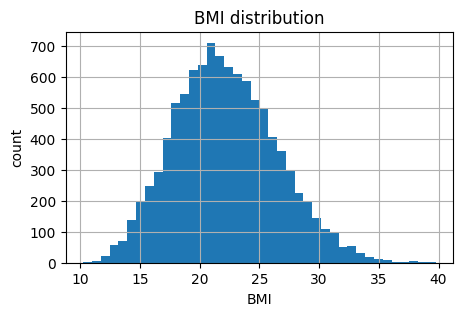

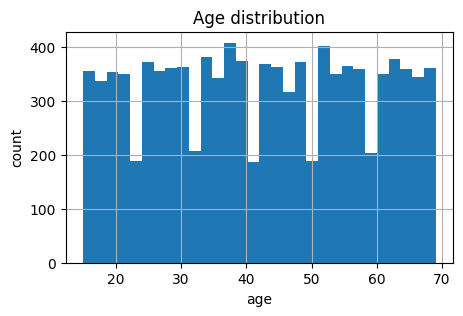

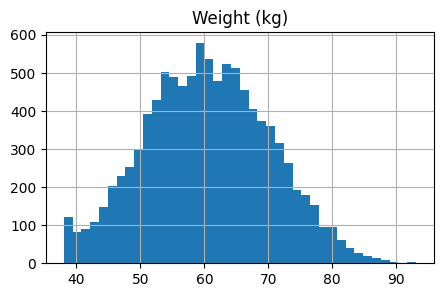

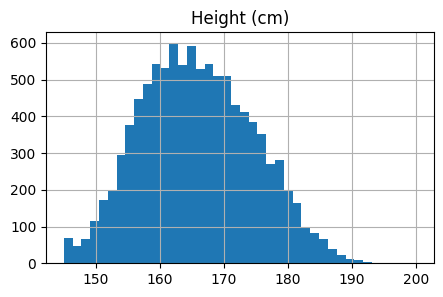

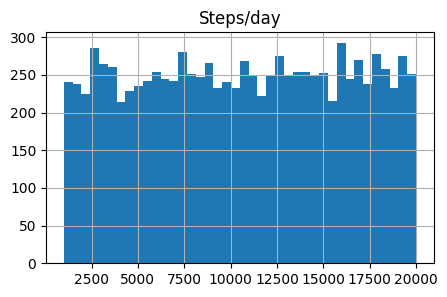


==================== LogReg — acc=0.989 | MAE=0.011 | RMSE=0.107 | time=0.1s ====================
              precision    recall  f1-score   support

      normal      0.990     0.989     0.989      1089
        over      0.982     0.990     0.986       504
       under      0.993     0.985     0.989       407

    accuracy                          0.989      2000
   macro avg      0.988     0.988     0.988      2000
weighted avg      0.989     0.989     0.989      2000



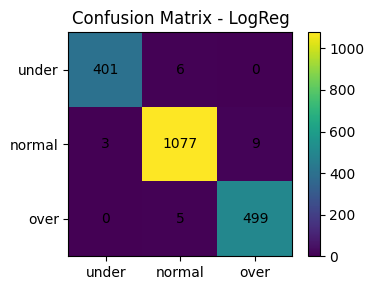


==================== SVM — acc=0.963 | MAE=0.037 | RMSE=0.192 | time=4.1s ====================
              precision    recall  f1-score   support

      normal      0.957     0.976     0.966      1089
        over      0.976     0.948     0.962       504
       under      0.965     0.946     0.955       407

    accuracy                          0.963      2000
   macro avg      0.966     0.957     0.961      2000
weighted avg      0.963     0.963     0.963      2000



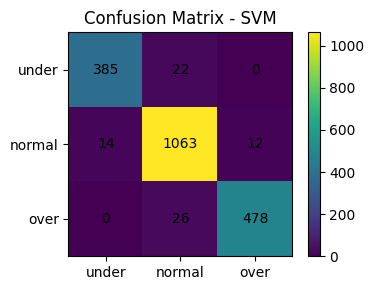


==================== KNN — acc=0.783 | MAE=0.217 | RMSE=0.466 | time=0.0s ====================
              precision    recall  f1-score   support

      normal      0.744     0.916     0.821      1089
        over      0.859     0.667     0.751       504
       under      0.866     0.570     0.687       407

    accuracy                          0.783      2000
   macro avg      0.823     0.718     0.753      2000
weighted avg      0.798     0.783     0.776      2000



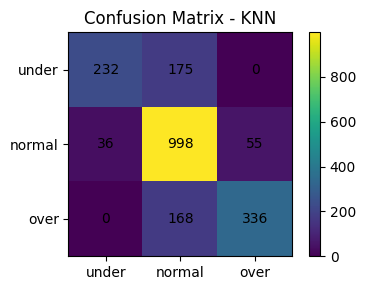


==================== DT — acc=0.978 | MAE=0.022 | RMSE=0.148 | time=0.1s ====================
              precision    recall  f1-score   support

      normal      0.975     0.985     0.980      1089
        over      0.982     0.964     0.973       504
       under      0.983     0.975     0.979       407

    accuracy                          0.978      2000
   macro avg      0.980     0.975     0.977      2000
weighted avg      0.978     0.978     0.978      2000



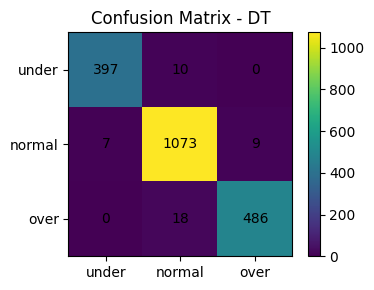


==================== RF — acc=0.916 | MAE=0.084 | RMSE=0.289 | time=1.9s ====================
              precision    recall  f1-score   support

      normal      0.879     0.982     0.928      1089
        over      0.971     0.857     0.910       504
       under      0.979     0.816     0.890       407

    accuracy                          0.916      2000
   macro avg      0.943     0.885     0.909      2000
weighted avg      0.923     0.916     0.916      2000



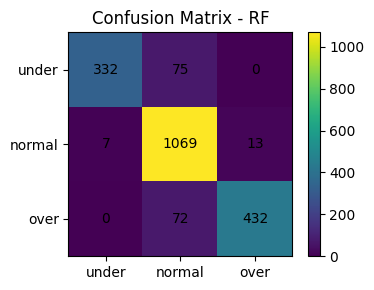


==================== TRAIN CNN / RNN / LSTM (graph mode) ====================
CNN Epoch 01 | loss=1.0205 | acc_val=0.544
CNN Epoch 02 | loss=0.9970 | acc_val=0.544
CNN Epoch 03 | loss=0.9873 | acc_val=0.544
CNN Epoch 04 | loss=0.9778 | acc_val=0.544
CNN Epoch 05 | loss=0.9678 | acc_val=0.549
CNN Epoch 06 | loss=0.9555 | acc_val=0.566
CNN Epoch 07 | loss=0.9384 | acc_val=0.570
CNN Epoch 08 | loss=0.9228 | acc_val=0.588
RNN Epoch 01 | loss=0.4326 | acc_val=0.844
RNN Epoch 02 | loss=0.2273 | acc_val=0.934
RNN Epoch 03 | loss=0.1830 | acc_val=0.939
RNN Epoch 04 | loss=0.1496 | acc_val=0.923
RNN Epoch 05 | loss=0.1444 | acc_val=0.943
RNN Epoch 06 | loss=0.1602 | acc_val=0.939
RNN Epoch 07 | loss=0.1238 | acc_val=0.950
RNN Epoch 08 | loss=0.1285 | acc_val=0.946
LSTM Epoch 01 | loss=0.9999 | acc_val=0.544
LSTM Epoch 02 | loss=0.9666 | acc_val=0.544
LSTM Epoch 03 | loss=0.9554 | acc_val=0.550
LSTM Epoch 04 | loss=0.9429 | acc_val=0.560
LSTM Epoch 05 | loss=0.9219 | acc_val=0.588
LSTM Epoch 06

C:\Users\Admin\AppData\Local\Temp\ipykernel_5656\932632014.py:411: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(col)["label"].apply(lambda s: np.mean(s=="over")).sort_values(ascending=False)


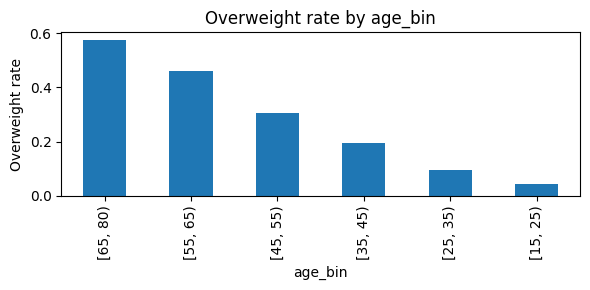

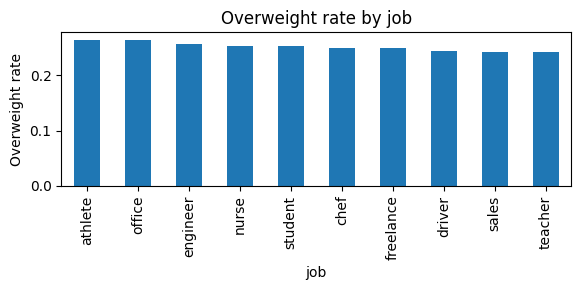

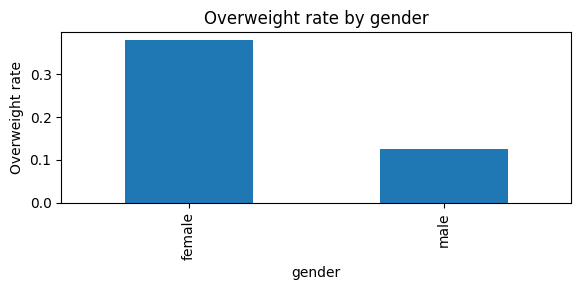

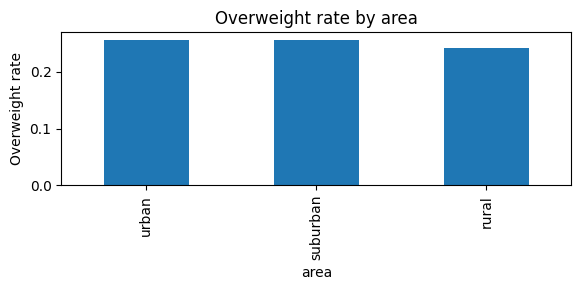


==================== DEPLOY MODEL = LogReg ====================

==================== KB READY ====================
KB file: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\kb_healthGuide_new.json | size MB: 3.22

==================== NHẬP THÔNG SỐ NGƯỜI DÙNG (Jupyter - text form) ====================


job [nurse]  options=['athlete', 'chef', 'driver', 'engineer', 'freelance', 'nurse', 'office', 'sales', 'student', 'teacher']:  
gender [male]  options=['female', 'male']:  
area [rural]  options=['rural', 'suburban', 'urban']:  
diet [vegetarian]  options=['balanced', 'dash', 'high_carb', 'high_fat', 'keto', 'mediterranean', 'vegetarian']:  
activity [high]  options=['high', 'low', 'medium']:  
age [42.0]:  
height_cm [165.5]:  
weight_kg [60.4]:  
sleep_h [7.0]:  
steps [10625.5]:  
sugar_g [59.6]:  
fat_g [66.1]:  
protein_g [65.9]:  
fiber_g [20.0]:  
waist_cm [75.8]:  
bp_sys [120.0]:  
bp_dia [77.0]:  
cholesterol [185.0]:  
smoker [1.0]:  
alcohol_units [10.0]:  



=== KẾT QUẢ DỰ ĐOÁN ===
Label: normal
BMI: 22.05
Xác suất:
  - normal : 1.000
  - over   : 0.000
  - under  : 0.000

Gợi ý sức khỏe (top):
  1. Duy trì năng lượng
  2. Ăn đa dạng
  3. Cardio 150 phút/tuần
  4. Tham vấn dinh dưỡng
  5. Giảm carb tinh luyện

==================== DONE — Files saved ====================
CSV: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\data_4.2_new.csv
KB : C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\kb_healthGuide_new.json


In [2]:

# ============================================
# ALL-IN-ONE CELL — Assignment 4.2 (NO KERAS)
# ============================================
# Author: Đỗ Ngọc Lâm – B22DCCN476 (template)
# Requirements:
#   pip install numpy pandas scikit-learn matplotlib tensorflow==2.15.*
# Lưu ý: KHÔNG dùng Keras. Dùng TF Core (tf.compat.v1) thuần graph mode.
# --------------------------------------------

import os, json, math, random, time, gc, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from datetime import datetime
from itertools import product

# -------------------------
# 0) ĐƯỜNG DẪN & TIỆN ÍCH
# -------------------------
WIN_PRIMARY = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"
FALLBACK    = os.path.abspath("./C_DATA")
OUT_DIR     = WIN_PRIMARY if (os.path.exists(WIN_PRIMARY) or os.name=="nt") else FALLBACK
os.makedirs(OUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(OUT_DIR, "data_4.2_new.csv")
KB_PATH  = os.path.join(OUT_DIR, "kb_healthGuide_new.json")

np.random.seed(42)
random.seed(42)

def print_bar(title):
    print("\n" + "="*20 + f" {title} " + "="*20)

# -------------------------
# 1) TẠO DATA (a)
# -------------------------
def synthesize_dataset(n=10000, seed=42):
    rng = np.random.default_rng(seed)
    jobs   = ["student","office","engineer","teacher","nurse","driver","athlete","freelance","chef","sales"]
    gender = ["male","female"]
    area   = ["urban","suburban","rural"]
    diet   = ["balanced","high_carb","high_fat","keto","vegetarian","mediterranean","dash"]
    act    = ["low","medium","high"]

    job      = rng.choice(jobs, n)
    gen      = rng.choice(gender, n)
    ar       = rng.choice(area, n)
    di       = rng.choice(diet, n)
    actlvl   = rng.choice(act, n)

    age      = rng.integers(15, 70, n)
    sleep_h  = rng.integers(5, 10, n)
    steps    = rng.integers(1000, 20000, n)

    base_h_male   = rng.normal(172, 7, n)
    base_h_female = rng.normal(160, 6, n)
    height_cm = np.where(gen=="male", base_h_male, base_h_female).clip(145, 200)

    base_w = 50 + 0.4*(age-18) + rng.normal(0, 6, n)
    base_w += np.where(actlvl=="low", 6, np.where(actlvl=="high",-4, 0))
    base_w += np.where(di=="high_carb", 3, 0)
    base_w += np.where(di=="keto",-2, 0)
    weight_kg = np.clip(base_w, 38, 130)

    sugar_g = (rng.normal(60, 20, n) 
               + np.where(di=="high_carb", 25, 0)
               - np.where(di=="keto", 25, 0)).clip(5, 160)
    fat_g   = (rng.normal(60, 20, n) 
               + np.where(di=="high_fat", 30, 0)
               + np.where(di=="keto", 20, 0)).clip(10, 160)
    protein_g = (rng.normal(60, 15, n) 
                 + np.where(actlvl=="high", 15, 0)
                 + np.where(di=="keto", 10, 0)).clip(20, 180)
    # FIX: dùng np.isin thay vì di.isin(...)
    fiber_g = (rng.normal(18, 6, n)
               + np.where(np.isin(di, ["vegetarian","mediterranean","dash"]), 5, 0)).clip(5, 50)

    waist_cm   = (rng.normal(0.45*height_cm, 6, n) + np.where(actlvl=="low", 4, 0)).clip(55, 140)
    bp_sys     = rng.normal(118, 15, n) + np.where(age>45, 6, 0) + np.where(di=="dash",-3, 0)
    bp_dia     = rng.normal(76, 10, n)  + np.where(age>45, 3, 0) + np.where(di=="dash",-2, 0)
    chol       = rng.normal(190, 35, n) + np.where(di=="mediterranean",-10, 0) + np.where(actlvl=="high",-8,0)

    smoker     = rng.integers(0, 2, n)
    alcohol    = rng.integers(0, 20, n)

    bmi = weight_kg / ((height_cm/100.0)**2)
    def bmi_label(x):
        if x < 18.5: return "under"
        if x < 25.0: return "normal"
        return "over"
    y_cls = np.array([bmi_label(x) for x in bmi])

    df = pd.DataFrame({
        # 20 features (5 cat + 15 num)
        "job":job, "gender":gen, "area":ar, "diet":di, "activity":actlvl,
        "age":age, "sleep_h":sleep_h, "steps":steps,
        "height_cm":height_cm.round(1), "weight_kg":weight_kg.round(1),
        "sugar_g":sugar_g.round(1), "fat_g":fat_g.round(1),
        "protein_g":protein_g.round(1), "fiber_g":fiber_g.round(1),
        "waist_cm":waist_cm.round(1),
        "bp_sys":bp_sys.round(0), "bp_dia":bp_dia.round(0),
        "cholesterol":chol.round(0),
        "smoker":smoker, "alcohol_units":alcohol,
        # tham chiếu
        "BMI":bmi.round(2), "label":y_cls
    })
    return df

if not os.path.exists(CSV_PATH):
    df = synthesize_dataset(10000)
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
else:
    df = pd.read_csv(CSV_PATH)

print_bar("DATA SHAPE")
print(df.shape)
print(df.head(3))

# -------------------------
# 2) PHÂN PHỐI (b)
# -------------------------
print_bar("DISTRIBUTIONS (showing plots)")
plt.figure(figsize=(5,3)); df["BMI"].hist(bins=40); plt.title("BMI distribution"); plt.xlabel("BMI"); plt.ylabel("count"); plt.show()
plt.figure(figsize=(5,3)); df["age"].hist(bins=30); plt.title("Age distribution"); plt.xlabel("age"); plt.ylabel("count"); plt.show()
plt.figure(figsize=(5,3)); df["weight_kg"].hist(bins=40); plt.title("Weight (kg)"); plt.show()
plt.figure(figsize=(5,3)); df["height_cm"].hist(bins=40); plt.title("Height (cm)"); plt.show()
plt.figure(figsize=(5,3)); df["steps"].hist(bins=40); plt.title("Steps/day"); plt.show()

# -------------------------
# 3) TIỀN XỬ LÝ + 5 ML MODELS (c)
# -------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

target = "label"
X = df.drop(columns=[target, "BMI"])
# X = df[["age", "job", "gender", "area", "diet"]]
y = df[target]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# FIX: buộc OHE trả về dense (tương thích sklearn mới/cũ)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer([
    ("cat", ohe, cat_cols),
    ("num", StandardScaler(), num_cols),
])

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "DT": DecisionTreeClassifier(max_depth=10, random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

ml_results = {}
for name, mdl in models.items():
    pipe = Pipeline([("pre", pre), ("clf", mdl)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    tr = time.time()-t0
    preds = pipe.predict(X_test)

    map_lbl = {"under":0, "normal":1, "over":2}
    y_true_num = np.array([map_lbl[v] for v in y_test])
    y_pred_num = np.array([map_lbl[v] for v in preds])

    acc = accuracy_score(y_test, preds)
    mae = mean_absolute_error(y_true_num, y_pred_num)
    mse = mean_squared_error(y_true_num, y_pred_num)
    rmse = math.sqrt(mse)

    ml_results[name] = {"acc":acc, "mae":mae, "mse":mse, "rmse":rmse, "time_s":tr, "pipe":pipe}
    print_bar(f"{name} — acc={acc:.3f} | MAE={mae:.3f} | RMSE={rmse:.3f} | time={tr:.1f}s")
    print(classification_report(y_test, preds, digits=3))
    cm = confusion_matrix(y_test, preds, labels=["under","normal","over"])
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}"); plt.colorbar()
    plt.xticks(range(3), ["under","normal","over"]); plt.yticks(range(3), ["under","normal","over"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# 4) DEEP LEARNING (d) — PURE TF v1 GRAPH MODE (NO KERAS at all)
# ----------------------------------------------------------------
# FIX: lấy preprocessor đã FIT trong mô hình tốt nhất và chỉ transform (không refit)
ref_pipe   = ml_results["RF"]["pipe"]
preproc    = ref_pipe.named_steps["pre"]

X_train_t = preproc.transform(X_train).astype(np.float32)  # dense
X_test_t  = preproc.transform(X_test).astype(np.float32)   # dense
feat_dim  = X_train_t.shape[1]
label2id  = {"under":0,"normal":1,"over":2}
y_train_id = np.array([label2id[v] for v in y_train], dtype=np.int32)
y_test_id  = np.array([label2id[v] for v in y_test],  dtype=np.int32)

import tensorflow as tf
tf.compat.v1.disable_eager_execution()
tf.random.set_seed(42)

num_classes = 3
hidden_size = 64
num_layers  = 5

# ---- 4.1 CNN-1D (graph mode) ----
g_cnn = tf.Graph()
with g_cnn.as_default():
    Xc = tf.compat.v1.placeholder(tf.float32, shape=[None, feat_dim], name="X")
    yc = tf.compat.v1.placeholder(tf.int32,   shape=[None],          name="y")
    x1 = tf.expand_dims(Xc, -1)  # [B, T=feat_dim, C=1]

    Wc1 = tf.Variable(tf.random.normal([5, 1, 32], stddev=0.1))
    Wc2 = tf.Variable(tf.random.normal([5, 32, 64], stddev=0.1))
    Wc3 = tf.Variable(tf.random.normal([3, 64, 64], stddev=0.1))
    z = tf.nn.relu(tf.nn.conv1d(x1, Wc1, stride=1, padding="SAME"))
    z = tf.nn.relu(tf.nn.conv1d(z,  Wc2, stride=1, padding="SAME"))
    z = tf.nn.relu(tf.nn.conv1d(z,  Wc3, stride=1, padding="SAME"))
    gap = tf.reduce_mean(z, axis=1)  # [B, 64]

    Wd1 = tf.Variable(tf.random.normal([64, 64], stddev=0.1)); bd1 = tf.Variable(tf.zeros([64]))
    Wo  = tf.Variable(tf.random.normal([64, num_classes], stddev=0.1)); bo = tf.Variable(tf.zeros([num_classes]))
    hid = tf.nn.relu(tf.matmul(gap, Wd1) + bd1)
    logits_cnn = tf.matmul(hid, Wo) + bo

    loss_cnn = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=yc, logits=logits_cnn))
    opt_cnn  = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss_cnn)
    pred_cnn = tf.argmax(logits_cnn, axis=1)
    acc_cnn  = tf.reduce_mean(tf.cast(tf.equal(pred_cnn, tf.cast(yc, tf.int64)), tf.float32))
    init_cnn = tf.compat.v1.global_variables_initializer()

def train_cnn_graph(epochs=8, batch=128):
    with tf.compat.v1.Session(graph=g_cnn) as sess:
        sess.run(init_cnn)
        n = X_train_t.shape[0]
        for ep in range(1, epochs+1):
            idx = np.random.permutation(n)
            Xp, yp = X_train_t[idx], y_train_id[idx]
            losses=[]
            for i in range(0, n, batch):
                xb = Xp[i:i+batch]; yb = yp[i:i+batch]
                _, l = sess.run([opt_cnn, loss_cnn], feed_dict={Xc:xb, yc:yb})
                losses.append(l)
            acc_val = sess.run(acc_cnn, feed_dict={Xc:X_test_t, yc:y_test_id})
            print(f"CNN Epoch {ep:02d} | loss={np.mean(losses):.4f} | acc_val={acc_val:.3f}")
        return float(acc_val)

# ---- 4.2 RNN (5 layers) thuần TF ----
def build_stacked_rnn_graph(feat_dim, hidden=64, layers=5, n_classes=3, scope="RNNcore"):
    g = tf.Graph()
    with g.as_default():
        X = tf.compat.v1.placeholder(tf.float32, shape=[None, feat_dim], name="X")  # [B, T]
        y = tf.compat.v1.placeholder(tf.int32,   shape=[None],          name="y")
        x_seq = tf.expand_dims(X, -1)  # [B, T, 1]

        params = []
        in_dim = 1
        for l in range(layers):
            with tf.compat.v1.variable_scope(f"{scope}_L{l}"):
                Wxh = tf.Variable(tf.random.normal([in_dim, hidden], stddev=0.1), name="Wxh")
                Whh = tf.Variable(tf.random.normal([hidden, hidden], stddev=0.1), name="Whh")
                b   = tf.Variable(tf.zeros([hidden]), name="b")
                params.append((Wxh, Whh, b))
            in_dim = hidden

        batch_size_dyn = tf.shape(X)[0]
        h_states = [tf.zeros([batch_size_dyn, hidden], dtype=tf.float32) for _ in range(layers)]

        def step_once(x_t, h_list):
            inp = x_t
            new_h = []
            for (Wxh, Whh, b), h_prev in zip(params, h_list):
                h = tf.tanh(tf.matmul(inp, Wxh) + tf.matmul(h_prev, Whh) + b)
                new_h.append(h)
                inp = h
            return new_h

        for t in range(feat_dim):
            x_t = x_seq[:, t, :]  # [B, 1]
            h_states = step_once(x_t, h_states)

        last_h = h_states[-1]
        Wo = tf.Variable(tf.random.normal([hidden, n_classes], stddev=0.1), name="Wo")
        bo = tf.Variable(tf.zeros([n_classes]), name="bo")
        logits = tf.matmul(last_h, Wo) + bo

        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
        train_op = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss)
        preds = tf.argmax(logits, axis=1)
        acc   = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(y, tf.int64)), tf.float32))
        init  = tf.compat.v1.global_variables_initializer()
    return {"graph":g, "X":X, "y":y, "loss":loss, "train_op":train_op, "acc":acc, "init":init}

# ---- 4.3 LSTM (5 layers) thuần TF ----
def build_stacked_lstm_graph(feat_dim, hidden=64, layers=5, n_classes=3, scope="LSTMcore"):
    g = tf.Graph()
    with g.as_default():
        X = tf.compat.v1.placeholder(tf.float32, shape=[None, feat_dim], name="X")
        y = tf.compat.v1.placeholder(tf.int32,   shape=[None],          name="y")
        x_seq = tf.expand_dims(X, -1)

        params = []
        in_dim = 1
        for l in range(layers):
            with tf.compat.v1.variable_scope(f"{scope}_L{l}"):
                W_x = tf.Variable(tf.random.normal([in_dim, 4*hidden], stddev=0.1), name="W_x")
                W_h = tf.Variable(tf.random.normal([hidden, 4*hidden], stddev=0.1), name="W_h")
                b   = tf.Variable(tf.zeros([4*hidden]), name="b")
                params.append((W_x, W_h, b))
            in_dim = hidden

        batch_size_dyn = tf.shape(X)[0]
        h_states = [tf.zeros([batch_size_dyn, hidden], dtype=tf.float32) for _ in range(layers)]
        c_states = [tf.zeros([batch_size_dyn, hidden], dtype=tf.float32) for _ in range(layers)]

        def sigmoid(z): return 1.0 / (1.0 + tf.exp(-z))

        def step_once(x_t, h_list, c_list):
            inp = x_t
            new_h, new_c = [], []
            for (W_x, W_h, b), h_prev, c_prev in zip(params, h_list, c_list):
                z = tf.matmul(inp, W_x) + tf.matmul(h_prev, W_h) + b   # [B, 4h]
                i, f, o, g = tf.split(z, num_or_size_splits=4, axis=1)
                i = sigmoid(i); f = sigmoid(f); o = sigmoid(o); g = tf.tanh(g)
                c = f * c_prev + i * g
                h = o * tf.tanh(c)
                new_h.append(h); new_c.append(c)
                inp = h
            return new_h, new_c

        for t in range(feat_dim):
            x_t = x_seq[:, t, :]
            h_states, c_states = step_once(x_t, h_states, c_states)

        last_h = h_states[-1]
        Wo = tf.Variable(tf.random.normal([hidden, n_classes], stddev=0.1), name="Wo")
        bo = tf.Variable(tf.zeros([n_classes]), name="bo")
        logits = tf.matmul(last_h, Wo) + bo

        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
        train_op = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss)
        preds = tf.argmax(logits, axis=1)
        acc   = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(y, tf.int64)), tf.float32))
        init  = tf.compat.v1.global_variables_initializer()
    return {"graph":g, "X":X, "y":y, "loss":loss, "train_op":train_op, "acc":acc, "init":init}

def train_graph_v1(graph_dict, Xtr, ytr, Xte, yte, epochs=8, batch=128, name="RNN"):
    g = graph_dict["graph"]
    with tf.compat.v1.Session(graph=g) as sess:
        sess.run(graph_dict["init"])
        n = Xtr.shape[0]
        for ep in range(1, epochs+1):
            idx = np.random.permutation(n)
            Xp, yp = Xtr[idx], ytr[idx]
            losses=[]
            for i in range(0, n, batch):
                xb = Xp[i:i+batch]; yb = yp[i:i+batch]
                _, l = sess.run([graph_dict["train_op"], graph_dict["loss"]],
                                feed_dict={graph_dict["X"]:xb, graph_dict["y"]:yb})
                losses.append(l)
            acc_val = sess.run(graph_dict["acc"], feed_dict={graph_dict["X"]:Xte, graph_dict["y"]:yte})
            print(f"{name} Epoch {ep:02d} | loss={np.mean(losses):.4f} | acc_val={acc_val:.3f}")
        return float(acc_val)

print_bar("TRAIN CNN / RNN / LSTM (graph mode)")
acc_cnn_val  = train_cnn_graph(epochs=8, batch=128)
rnn_graph    = build_stacked_rnn_graph(feat_dim, hidden=hidden_size, layers=num_layers, n_classes=num_classes)
lstm_graph   = build_stacked_lstm_graph(feat_dim, hidden=hidden_size, layers=num_layers, n_classes=num_classes)
acc_rnn_val  = train_graph_v1(rnn_graph,  X_train_t, y_train_id, X_test_t, y_test_id, epochs=8, batch=128, name="RNN")
acc_lstm_val = train_graph_v1(lstm_graph, X_train_t, y_train_id, X_test_t, y_test_id, epochs=8, batch=128, name="LSTM")

# -------------------------
# 5) SO SÁNH KẾT QUẢ (e)
# -------------------------
best_ml_name = max(ml_results, key=lambda k: ml_results[k]["acc"])
best_ml = ml_results[best_ml_name]
print_bar("ML SUMMARY")
for k, v in ml_results.items():
    print(f"{k:>5} | acc={v['acc']:.3f} | MAE={v['mae']:.3f} | RMSE={v['rmse']:.3f} | time={v['time_s']:.1f}s")

print_bar("DL SUMMARY (val acc)")
print(f"CNN  acc_val ≈ {acc_cnn_val:.3f}")
print(f"RNN  acc_val ≈ {acc_rnn_val:.3f}")
print(f"LSTM acc_val ≈ {acc_lstm_val:.3f}")

# -------------------------
# 6) VIZ: NHÓM THỪA CÂN (f)
# -------------------------
df["age_bin"] = pd.cut(df["age"], bins=[15,25,35,45,55,65,80], right=False)
def bar_counts(col):
    grp = df.groupby(col)["label"].apply(lambda s: np.mean(s=="over")).sort_values(ascending=False)
    plt.figure(figsize=(6,3))
    grp.plot(kind="bar"); plt.ylabel("Overweight rate")
    plt.title(f"Overweight rate by {col}"); plt.tight_layout(); plt.show()
    return grp

print_bar("Overweight by age_bin / job / gender / area")
ov_age   = bar_counts("age_bin")
ov_job   = bar_counts("job")
ov_gender= bar_counts("gender")
ov_area  = bar_counts("area")

# -------------------------
# 7) CHỌN MÔ HÌNH TỐT NHẤT & DEPLOY (g)
# -------------------------
overall_best = best_ml    # dùng mô hình ML tốt nhất để deploy
deploy_pipe  = overall_best["pipe"]
print_bar(f"DEPLOY MODEL = {best_ml_name}")

def deploy_predict(user_dict):
    """
    user_dict keys: job, gender, area, diet, activity, age, sleep_h, steps, height_cm,
                    weight_kg, sugar_g, fat_g, protein_g, fiber_g, waist_cm,
                    bp_sys, bp_dia, cholesterol, smoker, alcohol_units
    Trả về: label, probs
    """
    row = []
    for c in X.columns:
        if c in user_dict:
            row.append(user_dict[c])
        else:
            row.append(df[c].median() if c in num_cols else df[c].mode()[0])
    X1 = pd.DataFrame([row], columns=X.columns)
    pred = deploy_pipe.predict(X1)[0]
    if hasattr(deploy_pipe, "predict_proba"):
        pr = deploy_pipe.predict_proba(X1)[0]
        probs = {lbl: float(pr[i]) for i, lbl in enumerate(deploy_pipe.classes_)}
    else:
        probs = {lbl: 1.0/len(deploy_pipe.classes_) for lbl in deploy_pipe.classes_}
    return pred, probs

# -------------------------
# 8) SINH BIG KNOWLEDGE BASE (>3MB) (h)
# -------------------------
def build_big_kb(min_size_mb=3.2, seed=42, verbose=True):
    rng = random.Random(seed)
    kb = {
        "meta": {
            "version": "1.0",
            "generated_at": datetime.utcnow().isoformat() + "Z",
            "note": "Auto-synthesized KB for health guidance (diet/exercise/rules)"
        },
        "BMI_Classification": [],
        "Foods": [],
        "Exercise": [],
        "Meal_Plans": [],
        "Rules": []
    }

    bmi_vals = np.round(np.arange(15.0, 45.1, 0.1), 1)
    for b in bmi_vals:
        if b < 18.5:
            cat = "under"; advice = ["Tăng 200-300kcal/ngày","Protein 1.2-1.6g/kg","Tập sức mạnh 2-3 buổi/tuần"]
        elif b < 25:
            cat = "normal"; advice = ["Duy trì năng lượng","Ăn đa dạng","Cardio 150 phút/tuần"]
        elif b < 30:
            cat = "over"; advice = ["-300-500kcal/ngày","Ưu tiên rau, đạm nạc","Đi bộ nhanh 30-45'/ngày"]
        else:
            cat = "over"; advice = ["Tham vấn dinh dưỡng","Giảm carb tinh luyện","Theo dõi HA/cholesterol"]
        kb["BMI_Classification"].append({"bmi": float(b), "class": cat, "advice": advice})

    exercises = ["walk","jog","run","cycle","swim","row","yoga","pilates","hiit","pushup","squat","deadlift","bench","plank"]
    levels = ["easy","moderate","hard"]
    for i in range(400):
        ex = rng.choice(exercises); lvl= rng.choice(levels)
        kb["Exercise"].append({
            "id": f"EX{i:05d}",
            "name": ex, "level": lvl,
            "cal_burn_30min": int(rng.uniform(80, 500)),
            "suitable_for": rng.choice(["under","normal","over"]),
            "notes": "Auto-generated"
        })

    foods = ["brown_rice","oats","quinoa","chicken_breast","tofu","salmon","egg","apple","banana","spinach","broccoli","olive_oil","yogurt"]
    for i in range(5000):
        f = rng.choice(foods)
        kb["Foods"].append({
            "id": f"FD{i:05d}", "name": f,
            "cal_per_100g": round(rng.uniform(20, 600),1),
            "protein": round(rng.uniform(0, 40),1),
            "carb": round(rng.uniform(0, 80),1),
            "fat": round(rng.uniform(0, 50),1),
            "fiber": round(rng.uniform(0, 15),1),
            "gi": int(rng.uniform(10, 90))
        })

    for i in range(3500):
        goal = rng.choice(["loss","gain","maintain"])
        style= rng.choice(["mediterranean","dash","keto","balanced","vegetarian"])
        kcal = rng.choice([1200,1500,1800,2000,2200])
        kb["Meal_Plans"].append({
            "id": f"MP{i:05d}", "goal": goal, "style": style, "kcal": kcal,
            "items": rng.sample([f["id"] for f in kb["Foods"]], k=5)
        })

    combos = list(product(["under","normal","over"], ["low","medium","high"], ["diabetes","hypertension","none"]))
    rule_id=0
    for cls, act, dis in combos:
        for _ in range(350):  # ~9,450 rules
            rule = {
                "id": f"RL{rule_id:06d}",
                "if": {"class": cls, "activity": act, "disease": dis},
                "then": {
                    "risk": "moderate" if cls!="over" else "high",
                    "advice": rng.choice(kb["BMI_Classification"])["advice"]
                }
            }
            kb["Rules"].append(rule); rule_id+=1

    data = json.dumps(kb, ensure_ascii=False, indent=None).encode("utf-8")
    if verbose: print_bar(f"KB size ≈ {len(data)/1_000_000:.2f} MB")
    with open(KB_PATH, "wb") as f:
        f.write(data)
    return kb

if (not os.path.exists(KB_PATH)) or (os.path.getsize(KB_PATH) < 3_000_000):
    kb = build_big_kb(min_size_mb=3.2)
else:
    with open(KB_PATH,"rb") as f:
        kb = json.loads(f.read().decode("utf-8", errors="ignore"))

print_bar("KB READY")
print("KB file:", KB_PATH, "| size MB:", round(os.path.getsize(KB_PATH)/1_000_000,2))

# -------------------------
# 8.1 HÀM kb_chat — chọn gợi ý từ KB (FIX: bổ sung)
# -------------------------
def kb_chat(context, predicted_label):
    """
    context: {"BMI": float|None, "activity": "low|medium|high", "disease": "diabetes|hypertension|none"}
    predicted_label: "under|normal|over"
    return: {"advice": [str, ...], "source": {...}}
    """
    bmi = context.get("BMI", None)
    act = context.get("activity", "medium")
    dis = context.get("disease", "none")

    adv_list = []

    # 1) Theo BMI gần nhất (nếu có)
    if bmi is not None and "BMI_Classification" in kb and kb["BMI_Classification"]:
        # tìm entry có bmi gần nhất
        arr = kb["BMI_Classification"]
        idx = int(np.argmin([abs(bmi - e["bmi"]) for e in arr]))
        adv_list.extend(arr[idx]["advice"])

    # 2) Theo Rule khớp (class theo predicted_label)
    rules = kb.get("Rules", [])
    for r in rules:
        cond = r.get("if", {})
        if cond.get("class")==predicted_label and cond.get("activity")==act and cond.get("disease")==dis:
            adv_list.extend(r.get("then", {}).get("advice", []))
            # lấy 1-2 rule là đủ
            if len(adv_list) >= 6:
                break

    # 3) Fallback nếu vẫn rỗng
    if not adv_list:
        adv_list = ["Uống đủ nước", "Ngủ 7-8 giờ", "Tăng rau xanh & trái cây", "Giảm đồ ngọt & nước có ga"]

    # Loại trùng, cắt top 5
    uniq = []
    for a in adv_list:
        if a not in uniq:
            uniq.append(a)
    return {"advice": uniq[:5], "source": {"predicted_label": predicted_label, "activity": act, "disease": dis}}

# -------------------------
# ===============================
# (9) UI đơn giản nhập thông số
# ===============================
def _default_row():
    # Lấy giá trị mặc định: số = median, cat = mode
    row = {}
    for c in X.columns:
        if c in num_cols:
            row[c] = float(df[c].median())
        else:
            row[c] = str(df[c].mode()[0])
    return row

def _predict_and_print(user_dict):
    # Tính BMI để tư vấn thêm
    h = float(user_dict["height_cm"])
    w = float(user_dict["weight_kg"])
    bmi = w / ((h/100.0)**2) if h > 0 else None

    pred, probs = deploy_predict(user_dict)
    adv = kb_chat({"BMI": bmi, "activity": user_dict.get("activity","medium"), "disease": user_dict.get("disease","none")}, pred)

    print("\n=== KẾT QUẢ DỰ ĐOÁN ===")
    print(f"Label: {pred}")
    if bmi is not None:
        print(f"BMI: {bmi:.2f}")
    print("Xác suất:")
    for k,v in probs.items():
        print(f"  - {k:7s}: {v:.3f}")
    print("\nGợi ý sức khỏe (top):")
    for i, tip in enumerate(adv["advice"], 1):
        print(f"  {i}. {tip}")

# ===============================
# (9) UI đơn giản nhập thông số — Jupyter friendly (NO ipywidgets)
# ===============================
USE_WIDGETS = False  # Đổi True nếu bạn muốn dùng ipywidgets (khi đã cài)

def _default_row():
    row = {}
    for c in X.columns:
        if c in num_cols:
            row[c] = float(df[c].median())
        else:
            row[c] = str(df[c].mode()[0])
    return row

def _predict_and_print(user_dict):
    h = float(user_dict["height_cm"])
    w = float(user_dict["weight_kg"])
    bmi = w / ((h/100.0)**2) if h > 0 else None

    pred, probs = deploy_predict(user_dict)
    adv = kb_chat({"BMI": bmi, "activity": user_dict.get("activity","medium"), "disease": user_dict.get("disease","none")}, pred)

    print("\n=== KẾT QUẢ DỰ ĐOÁN ===")
    print(f"Label: {pred}")
    if bmi is not None:
        print(f"BMI: {bmi:.2f}")
    print("Xác suất:")
    for k,v in probs.items():
        print(f"  - {k:7s}: {v:.3f}")
    print("\nGợi ý sức khỏe (top):")
    for i, tip in enumerate(adv["advice"], 1):
        print(f"  {i}. {tip}")

def _ask_input(prompt, default, allowed=None, cast=float):
    """
    Hỏi người dùng (Jupyter/Notebook friendly). Enter để lấy default.
    allowed: list các lựa chọn hợp lệ (cho cột phân loại) hoặc None.
    """
    ds = f" [{default}]"
    if allowed:
        ds += f"  options={allowed}"
    s = input(f"{prompt}{ds}: ").strip()
    if s == "":
        return default
    if allowed and s not in allowed:
        print(f"--> Không hợp lệ, dùng mặc định: {default}")
        return default
    try:
        return cast(s)
    except:
        print(f"--> Không ép kiểu được, dùng mặc định: {default}")
        return default

def run_text_form():
    print_bar("NHẬP THÔNG SỐ NGƯỜI DÙNG (Jupyter - text form)")
    defaults = _default_row()

    # 1) Categorical trước để phù hợp đề: age, job, gender, area, diet (+ activity)
    user = {}
    cat_order = [c for c in ["job","gender","area","diet","activity"] if c in X.columns]
    for c in cat_order:
        opts = sorted(df[c].astype(str).unique().tolist())
        user[c] = _ask_input(c, defaults.get(c, opts[0] if opts else ""), allowed=opts, cast=str)

    # 2) Numeric: gom các cột số hiện có trong X
    #    Nếu X chỉ có 5 cột (age, job, gender, area, diet), ta vẫn hỏi thêm các numeric cần thiết
    #    để tính BMI và dự đoán chính xác (height_cm, weight_kg, ...). Nếu không có trong X,
    #    deploy_predict sẽ tự dùng median/mode; tuy nhiên ta nên hỏi age/height/weight tối thiểu.
    numeric_specs = {
        "age": (15, 100, int),
        "sleep_h": (0, 24, int),
        "steps": (0, 100000, int),
        "height_cm": (100, 220, float),
        "weight_kg": (30, 200, float),
        "sugar_g": (0, 300, float),
        "fat_g": (0, 300, float),
        "protein_g": (0, 300, float),
        "fiber_g": (0, 100, float),
        "waist_cm": (40, 200, float),
        "bp_sys": (70, 220, int),
        "bp_dia": (40, 140, int),
        "cholesterol": (80, 400, int),
        "smoker": (0, 1, int),
        "alcohol_units": (0, 50, int),
    }

    # Bắt buộc hỏi 3 biến “cốt lõi” để BMI & dự đoán hợp lý
    core_numeric = ["age","height_cm","weight_kg"]
    for c in core_numeric:
        lo, hi, caster = numeric_specs[c]
        default = defaults.get(c, lo)
        user[c] = _ask_input(c, default, allowed=None, cast=caster)

    # Hỏi thêm các numeric còn lại NẾU chúng có trong X hoặc bạn muốn bổ sung để dự đoán tốt hơn
    more_numeric = [c for c in numeric_specs.keys() if c not in core_numeric]
    for c in more_numeric:
        default = defaults.get(c, numeric_specs[c][0])
        caster  = numeric_specs[c][2]
        # Nếu cột này thuộc X hiện tại thì nên hỏi; nếu không thuộc X vẫn có ích cho deploy_predict
        ask = True
        if ask:
            user[c] = _ask_input(c, default, allowed=None, cast=caster)

    # Đảm bảo mọi key trong X đều có mặt trong user (nếu thiếu sẽ dùng median/mode ở deploy_predict)
    for c in X.columns:
        if c not in user:
            user[c] = defaults[c] if c in defaults else (0.0 if c in num_cols else str(df[c].mode()[0]))

    _predict_and_print(user)

if USE_WIDGETS:
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        dropdowns = {}
        for c in [col for col in X.columns if c in cat_cols]:
            opts = sorted(df[c].astype(str).unique().tolist())
            dropdowns[c] = widgets.Dropdown(options=opts, value=opts[0], description=c, layout=widgets.Layout(width="300px"))

        num_inputs = {}
        defaults = _default_row()
        # đơn giản hoá: dùng FloatText/IntText như trước
        for c in [col for col in X.columns if c in num_cols]:
            val = defaults.get(c, 0)
            if float(val).is_integer():
                num_inputs[c] = widgets.IntText(value=int(val), description=c, layout=widgets.Layout(width="300px"))
            else:
                num_inputs[c] = widgets.FloatText(value=float(val), description=c, layout=widgets.Layout(width="300px"))

        btn = widgets.Button(description="Dự đoán", button_style="primary")
        out = widgets.Output()

        def on_click_predict(_):
            with out:
                clear_output()
                user = {}
                for c, w in dropdowns.items(): user[c] = w.value
                for c, w in num_inputs.items(): user[c] = float(w.value)
                _predict_and_print(user)

        btn.on_click(on_click_predict)

        cat_box = widgets.VBox([dropdowns[c] for c in ["job","gender","area","diet","activity"] if c in dropdowns])
        ncols = [widgets.VBox([]), widgets.VBox([])]
        i = 0
        for c in ["age","sleep_h","steps","height_cm","weight_kg","sugar_g","fat_g","protein_g","fiber_g",
                  "waist_cm","bp_sys","bp_dia","cholesterol","smoker","alcohol_units"]:
            if c in num_inputs:
                ncols[i%2].children = tuple(list(ncols[i%2].children)+[num_inputs[c]])
                i += 1
        num_box = widgets.HBox(ncols)

        ui = widgets.VBox([
            widgets.HTML("<h3>Nhập thông số người dùng</h3>"),
            cat_box,
            widgets.HTML("<hr>"),
            num_box,
            widgets.HTML("<br>"),
            btn,
            widgets.HTML("<hr>"),
            out
        ])
        display(ui)
    except Exception as _e:
        print("ipywidgets không khả dụng → dùng text form.")
        run_text_form()
else:
    run_text_form()

print_bar("DONE — Files saved")
print("CSV:", CSV_PATH)
print("KB :", KB_PATH)



==================== DATA SHAPE ====================
(10000, 22)
         job  gender   area       diet activity  age  sleep_h  steps  \
0    student    male  urban  high_carb     high   20        5  15838   
1  freelance    male  rural   high_fat     high   67        6   3618   
2    athlete  female  urban       dash      low   43        8   6786   

   height_cm  weight_kg  ...  protein_g  fiber_g  waist_cm  bp_sys  bp_dia  \
0      176.3       50.8  ...       68.9     20.4      79.8   118.0    68.0   
1      152.4       75.5  ...       49.0     21.5      68.5   119.0    75.0   
2      165.1       66.9  ...       69.3     22.5      75.0   113.0    82.0   

   cholesterol  smoker  alcohol_units    BMI   label  
0        192.0       0              8  16.35   under  
1        201.0       1              7  32.50    over  
2        261.0       0             12  24.54  normal  

[3 rows x 22 columns]

==================== DISTRIBUTIONS (showing plots) ====================


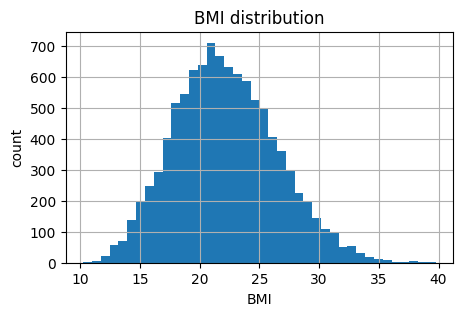

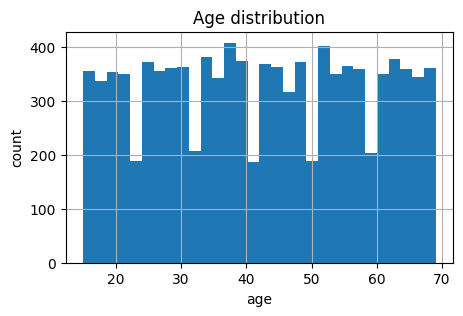

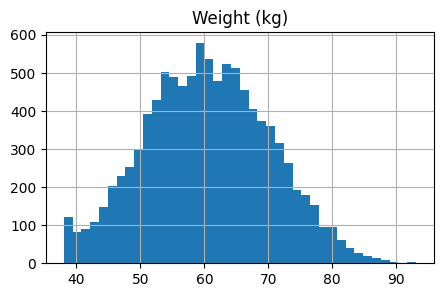

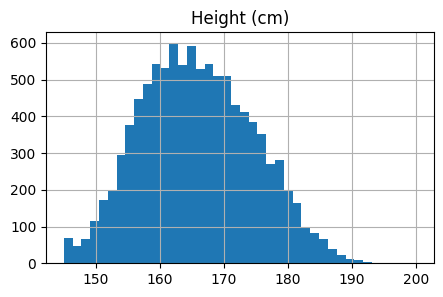

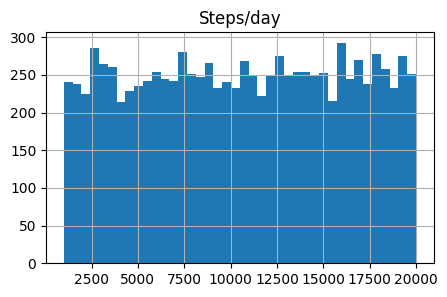


==================== LogReg — acc=0.989 | MAE=0.011 | RMSE=0.107 | time=0.1s ====================
              precision    recall  f1-score   support

      normal      0.990     0.989     0.989      1089
        over      0.982     0.990     0.986       504
       under      0.993     0.985     0.989       407

    accuracy                          0.989      2000
   macro avg      0.988     0.988     0.988      2000
weighted avg      0.989     0.989     0.989      2000



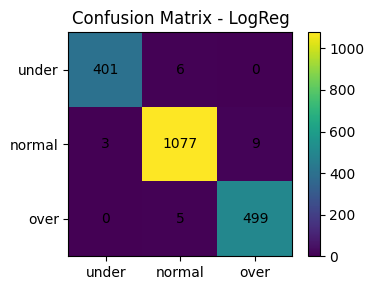


==================== SVM — acc=0.963 | MAE=0.037 | RMSE=0.192 | time=4.4s ====================
              precision    recall  f1-score   support

      normal      0.957     0.976     0.966      1089
        over      0.976     0.948     0.962       504
       under      0.965     0.946     0.955       407

    accuracy                          0.963      2000
   macro avg      0.966     0.957     0.961      2000
weighted avg      0.963     0.963     0.963      2000



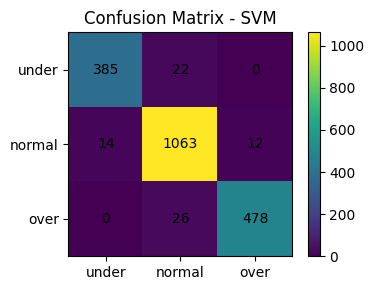


==================== KNN — acc=0.783 | MAE=0.217 | RMSE=0.466 | time=0.0s ====================
              precision    recall  f1-score   support

      normal      0.744     0.916     0.821      1089
        over      0.859     0.667     0.751       504
       under      0.866     0.570     0.687       407

    accuracy                          0.783      2000
   macro avg      0.823     0.718     0.753      2000
weighted avg      0.798     0.783     0.776      2000



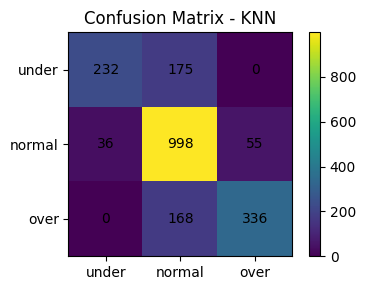


==================== DT — acc=0.978 | MAE=0.022 | RMSE=0.148 | time=0.1s ====================
              precision    recall  f1-score   support

      normal      0.975     0.985     0.980      1089
        over      0.982     0.964     0.973       504
       under      0.983     0.975     0.979       407

    accuracy                          0.978      2000
   macro avg      0.980     0.975     0.977      2000
weighted avg      0.978     0.978     0.978      2000



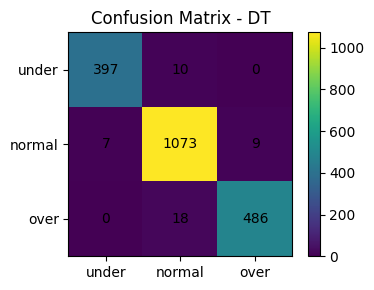


==================== RF — acc=0.916 | MAE=0.084 | RMSE=0.289 | time=2.0s ====================
              precision    recall  f1-score   support

      normal      0.879     0.982     0.928      1089
        over      0.971     0.857     0.910       504
       under      0.979     0.816     0.890       407

    accuracy                          0.916      2000
   macro avg      0.943     0.885     0.909      2000
weighted avg      0.923     0.916     0.916      2000



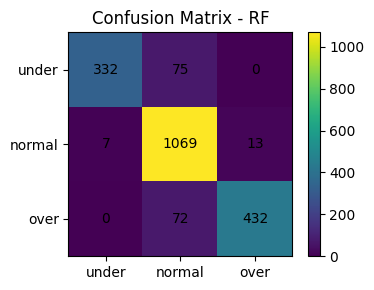


==================== TRAIN CNN / RNN / LSTM (graph mode) ====================
CNN Epoch 01 | loss=1.0208 | acc_val=0.544
CNN Epoch 02 | loss=0.9917 | acc_val=0.544
CNN Epoch 03 | loss=0.9874 | acc_val=0.544
CNN Epoch 04 | loss=0.9804 | acc_val=0.544
CNN Epoch 05 | loss=0.9741 | acc_val=0.550
CNN Epoch 06 | loss=0.9610 | acc_val=0.552
CNN Epoch 07 | loss=0.9447 | acc_val=0.558
CNN Epoch 08 | loss=0.9244 | acc_val=0.586
RNN Epoch 01 | loss=0.4520 | acc_val=0.885
RNN Epoch 02 | loss=0.2327 | acc_val=0.928
RNN Epoch 03 | loss=0.1857 | acc_val=0.930
RNN Epoch 04 | loss=0.1537 | acc_val=0.925
RNN Epoch 05 | loss=0.1594 | acc_val=0.942
RNN Epoch 06 | loss=0.1412 | acc_val=0.939
RNN Epoch 07 | loss=0.1325 | acc_val=0.957
RNN Epoch 08 | loss=0.1254 | acc_val=0.942
LSTM Epoch 01 | loss=1.0066 | acc_val=0.544
LSTM Epoch 02 | loss=0.9629 | acc_val=0.544
LSTM Epoch 03 | loss=0.9536 | acc_val=0.543
LSTM Epoch 04 | loss=0.9433 | acc_val=0.546
LSTM Epoch 05 | loss=0.9072 | acc_val=0.579
LSTM Epoch 06

C:\Users\Admin\AppData\Local\Temp\ipykernel_5656\1991378086.py:411: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(col)["label"].apply(lambda s: np.mean(s=="over")).sort_values(ascending=False)


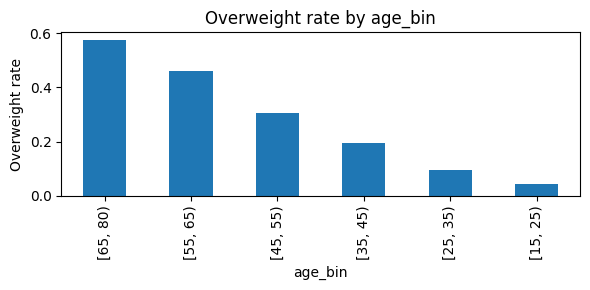

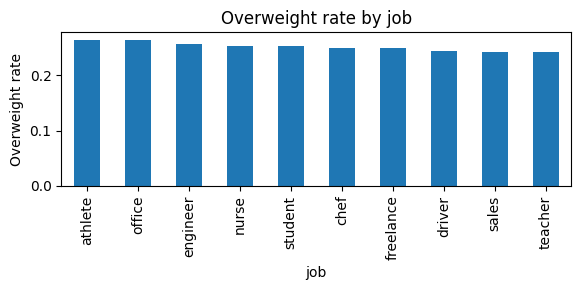

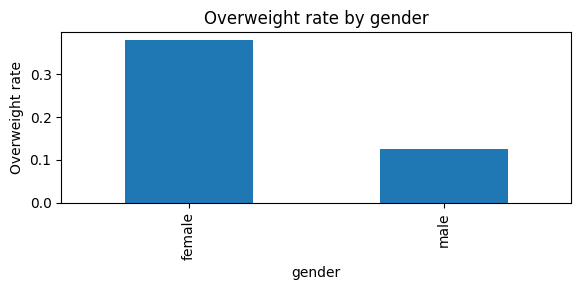

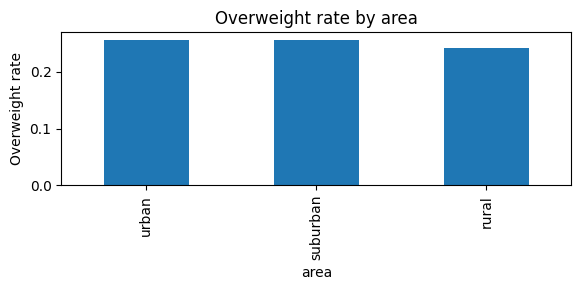


==================== DEPLOY MODEL = LogReg ====================

==================== KB READY ====================
KB file: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\kb_healthGuide_new.json | size MB: 3.22

==================== NHẬP THÔNG SỐ NGƯỜI DÙNG (Jupyter - text form) ====================


job [nurse]  options=['athlete', 'chef', 'driver', 'engineer', 'freelance', 'nurse', 'office', 'sales', 'student', 'teacher']:  
gender [male]  options=['female', 'male']:  
area [rural]  options=['rural', 'suburban', 'urban']:  
diet [vegetarian]  options=['balanced', 'dash', 'high_carb', 'high_fat', 'keto', 'mediterranean', 'vegetarian']:  
activity [high]  options=['high', 'low', 'medium']:  
disease [none]  options=['none', 'diabetes', 'hypertension']:  
age [42.0]:  
height_cm [165.5]:  
weight_kg [60.4]:  
sleep_h [7.0]:  
steps [10625.5]:  
sugar_g [59.6]:  
fat_g [66.1]:  
protein_g [65.9]:  
fiber_g [20.0]:  
waist_cm [75.8]:  
bp_sys [120.0]:  
bp_dia [77.0]:  
cholesterol [185.0]:  
smoker [1.0]:  
alcohol_units [10.0]:  



=== KẾT QUẢ DỰ ĐOÁN ===
Label: normal
BMI: 22.05

Xác suất dự đoán:
  - normal : 1.000
  - over   : 0.000
  - under  : 0.000

=== GUIDE TỪ KB ===
  • Theo dự đoán: class='normal', activity='high', disease='none'
  • BMI gần nhất trong KB: 22.1
  • Rule áp dụng: RL005950, RL005951, RL005952
  • Gợi ý (top):
     1. Duy trì năng lượng
     2. Ăn đa dạng
     3. Cardio 150 phút/tuần
     4. Tham vấn dinh dưỡng
     5. Giảm carb tinh luyện

==================== DONE — Files saved ====================
CSV: C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\data_4.2_new.csv
KB : C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4\kb_healthGuide_new.json


In [3]:

# ============================================
# ALL-IN-ONE CELL — Assignment 4.2 (NO KERAS)
# ============================================
# Author: Đỗ Ngọc Lâm – B22DCCN476 (template)
# Requirements:
#   pip install numpy pandas scikit-learn matplotlib tensorflow==2.15.*
# Lưu ý: KHÔNG dùng Keras. Dùng TF Core (tf.compat.v1) thuần graph mode.
# --------------------------------------------

import os, json, math, random, time, gc, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from datetime import datetime
from itertools import product

# -------------------------
# 0) ĐƯỜNG DẪN & TIỆN ÍCH
# -------------------------
WIN_PRIMARY = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\assignment_4"
FALLBACK    = os.path.abspath("./C_DATA")
OUT_DIR     = WIN_PRIMARY if (os.path.exists(WIN_PRIMARY) or os.name=="nt") else FALLBACK
os.makedirs(OUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(OUT_DIR, "data_4.2_new.csv")
KB_PATH  = os.path.join(OUT_DIR, "kb_healthGuide_new.json")

np.random.seed(42)
random.seed(42)

def print_bar(title):
    print("\n" + "="*20 + f" {title} " + "="*20)

# -------------------------
# 1) TẠO DATA (a)
# -------------------------
def synthesize_dataset(n=10000, seed=42):
    rng = np.random.default_rng(seed)
    jobs   = ["student","office","engineer","teacher","nurse","driver","athlete","freelance","chef","sales"]
    gender = ["male","female"]
    area   = ["urban","suburban","rural"]
    diet   = ["balanced","high_carb","high_fat","keto","vegetarian","mediterranean","dash"]
    act    = ["low","medium","high"]

    job      = rng.choice(jobs, n)
    gen      = rng.choice(gender, n)
    ar       = rng.choice(area, n)
    di       = rng.choice(diet, n)
    actlvl   = rng.choice(act, n)

    age      = rng.integers(15, 70, n)
    sleep_h  = rng.integers(5, 10, n)
    steps    = rng.integers(1000, 20000, n)

    base_h_male   = rng.normal(172, 7, n)
    base_h_female = rng.normal(160, 6, n)
    height_cm = np.where(gen=="male", base_h_male, base_h_female).clip(145, 200)

    base_w = 50 + 0.4*(age-18) + rng.normal(0, 6, n)
    base_w += np.where(actlvl=="low", 6, np.where(actlvl=="high",-4, 0))
    base_w += np.where(di=="high_carb", 3, 0)
    base_w += np.where(di=="keto",-2, 0)
    weight_kg = np.clip(base_w, 38, 130)

    sugar_g = (rng.normal(60, 20, n) 
               + np.where(di=="high_carb", 25, 0)
               - np.where(di=="keto", 25, 0)).clip(5, 160)
    fat_g   = (rng.normal(60, 20, n) 
               + np.where(di=="high_fat", 30, 0)
               + np.where(di=="keto", 20, 0)).clip(10, 160)
    protein_g = (rng.normal(60, 15, n) 
                 + np.where(actlvl=="high", 15, 0)
                 + np.where(di=="keto", 10, 0)).clip(20, 180)
    # FIX: dùng np.isin thay vì di.isin(...)
    fiber_g = (rng.normal(18, 6, n)
               + np.where(np.isin(di, ["vegetarian","mediterranean","dash"]), 5, 0)).clip(5, 50)

    waist_cm   = (rng.normal(0.45*height_cm, 6, n) + np.where(actlvl=="low", 4, 0)).clip(55, 140)
    bp_sys     = rng.normal(118, 15, n) + np.where(age>45, 6, 0) + np.where(di=="dash",-3, 0)
    bp_dia     = rng.normal(76, 10, n)  + np.where(age>45, 3, 0) + np.where(di=="dash",-2, 0)
    chol       = rng.normal(190, 35, n) + np.where(di=="mediterranean",-10, 0) + np.where(actlvl=="high",-8,0)

    smoker     = rng.integers(0, 2, n)
    alcohol    = rng.integers(0, 20, n)

    bmi = weight_kg / ((height_cm/100.0)**2)
    def bmi_label(x):
        if x < 18.5: return "under"
        if x < 25.0: return "normal"
        return "over"
    y_cls = np.array([bmi_label(x) for x in bmi])

    df = pd.DataFrame({
        # 20 features (5 cat + 15 num)
        "job":job, "gender":gen, "area":ar, "diet":di, "activity":actlvl,
        "age":age, "sleep_h":sleep_h, "steps":steps,
        "height_cm":height_cm.round(1), "weight_kg":weight_kg.round(1),
        "sugar_g":sugar_g.round(1), "fat_g":fat_g.round(1),
        "protein_g":protein_g.round(1), "fiber_g":fiber_g.round(1),
        "waist_cm":waist_cm.round(1),
        "bp_sys":bp_sys.round(0), "bp_dia":bp_dia.round(0),
        "cholesterol":chol.round(0),
        "smoker":smoker, "alcohol_units":alcohol,
        # tham chiếu
        "BMI":bmi.round(2), "label":y_cls
    })
    return df

if not os.path.exists(CSV_PATH):
    df = synthesize_dataset(10000)
    df.to_csv(CSV_PATH, index=False, encoding="utf-8")
else:
    df = pd.read_csv(CSV_PATH)

print_bar("DATA SHAPE")
print(df.shape)
print(df.head(3))

# -------------------------
# 2) PHÂN PHỐI (b)
# -------------------------
print_bar("DISTRIBUTIONS (showing plots)")
plt.figure(figsize=(5,3)); df["BMI"].hist(bins=40); plt.title("BMI distribution"); plt.xlabel("BMI"); plt.ylabel("count"); plt.show()
plt.figure(figsize=(5,3)); df["age"].hist(bins=30); plt.title("Age distribution"); plt.xlabel("age"); plt.ylabel("count"); plt.show()
plt.figure(figsize=(5,3)); df["weight_kg"].hist(bins=40); plt.title("Weight (kg)"); plt.show()
plt.figure(figsize=(5,3)); df["height_cm"].hist(bins=40); plt.title("Height (cm)"); plt.show()
plt.figure(figsize=(5,3)); df["steps"].hist(bins=40); plt.title("Steps/day"); plt.show()

# -------------------------
# 3) TIỀN XỬ LÝ + 5 ML MODELS (c)
# -------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

target = "label"
X = df.drop(columns=[target, "BMI"])
# X = df[["age", "job", "gender", "area", "diet"]]
y = df[target]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# FIX: buộc OHE trả về dense (tương thích sklearn mới/cũ)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer([
    ("cat", ohe, cat_cols),
    ("num", StandardScaler(), num_cols),
])

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "DT": DecisionTreeClassifier(max_depth=10, random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

ml_results = {}
for name, mdl in models.items():
    pipe = Pipeline([("pre", pre), ("clf", mdl)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    tr = time.time()-t0
    preds = pipe.predict(X_test)

    map_lbl = {"under":0, "normal":1, "over":2}
    y_true_num = np.array([map_lbl[v] for v in y_test])
    y_pred_num = np.array([map_lbl[v] for v in preds])

    acc = accuracy_score(y_test, preds)
    mae = mean_absolute_error(y_true_num, y_pred_num)
    mse = mean_squared_error(y_true_num, y_pred_num)
    rmse = math.sqrt(mse)

    ml_results[name] = {"acc":acc, "mae":mae, "mse":mse, "rmse":rmse, "time_s":tr, "pipe":pipe}
    print_bar(f"{name} — acc={acc:.3f} | MAE={mae:.3f} | RMSE={rmse:.3f} | time={tr:.1f}s")
    print(classification_report(y_test, preds, digits=3))
    cm = confusion_matrix(y_test, preds, labels=["under","normal","over"])
    plt.figure(figsize=(4,3))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}"); plt.colorbar()
    plt.xticks(range(3), ["under","normal","over"]); plt.yticks(range(3), ["under","normal","over"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.tight_layout(); plt.show()

# ----------------------------------------------------------------
# 4) DEEP LEARNING (d) — PURE TF v1 GRAPH MODE (NO KERAS at all)
# ----------------------------------------------------------------
# FIX: lấy preprocessor đã FIT trong mô hình tốt nhất và chỉ transform (không refit)
ref_pipe   = ml_results["RF"]["pipe"]
preproc    = ref_pipe.named_steps["pre"]

X_train_t = preproc.transform(X_train).astype(np.float32)  # dense
X_test_t  = preproc.transform(X_test).astype(np.float32)   # dense
feat_dim  = X_train_t.shape[1]
label2id  = {"under":0,"normal":1,"over":2}
y_train_id = np.array([label2id[v] for v in y_train], dtype=np.int32)
y_test_id  = np.array([label2id[v] for v in y_test],  dtype=np.int32)

import tensorflow as tf
tf.compat.v1.disable_eager_execution()
tf.random.set_seed(42)

num_classes = 3
hidden_size = 64
num_layers  = 5

# ---- 4.1 CNN-1D (graph mode) ----
g_cnn = tf.Graph()
with g_cnn.as_default():
    Xc = tf.compat.v1.placeholder(tf.float32, shape=[None, feat_dim], name="X")
    yc = tf.compat.v1.placeholder(tf.int32,   shape=[None],          name="y")
    x1 = tf.expand_dims(Xc, -1)  # [B, T=feat_dim, C=1]

    Wc1 = tf.Variable(tf.random.normal([5, 1, 32], stddev=0.1))
    Wc2 = tf.Variable(tf.random.normal([5, 32, 64], stddev=0.1))
    Wc3 = tf.Variable(tf.random.normal([3, 64, 64], stddev=0.1))
    z = tf.nn.relu(tf.nn.conv1d(x1, Wc1, stride=1, padding="SAME"))
    z = tf.nn.relu(tf.nn.conv1d(z,  Wc2, stride=1, padding="SAME"))
    z = tf.nn.relu(tf.nn.conv1d(z,  Wc3, stride=1, padding="SAME"))
    gap = tf.reduce_mean(z, axis=1)  # [B, 64]

    Wd1 = tf.Variable(tf.random.normal([64, 64], stddev=0.1)); bd1 = tf.Variable(tf.zeros([64]))
    Wo  = tf.Variable(tf.random.normal([64, num_classes], stddev=0.1)); bo = tf.Variable(tf.zeros([num_classes]))
    hid = tf.nn.relu(tf.matmul(gap, Wd1) + bd1)
    logits_cnn = tf.matmul(hid, Wo) + bo

    loss_cnn = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=yc, logits=logits_cnn))
    opt_cnn  = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss_cnn)
    pred_cnn = tf.argmax(logits_cnn, axis=1)
    acc_cnn  = tf.reduce_mean(tf.cast(tf.equal(pred_cnn, tf.cast(yc, tf.int64)), tf.float32))
    init_cnn = tf.compat.v1.global_variables_initializer()

def train_cnn_graph(epochs=8, batch=128):
    with tf.compat.v1.Session(graph=g_cnn) as sess:
        sess.run(init_cnn)
        n = X_train_t.shape[0]
        for ep in range(1, epochs+1):
            idx = np.random.permutation(n)
            Xp, yp = X_train_t[idx], y_train_id[idx]
            losses=[]
            for i in range(0, n, batch):
                xb = Xp[i:i+batch]; yb = yp[i:i+batch]
                _, l = sess.run([opt_cnn, loss_cnn], feed_dict={Xc:xb, yc:yb})
                losses.append(l)
            acc_val = sess.run(acc_cnn, feed_dict={Xc:X_test_t, yc:y_test_id})
            print(f"CNN Epoch {ep:02d} | loss={np.mean(losses):.4f} | acc_val={acc_val:.3f}")
        return float(acc_val)

# ---- 4.2 RNN (5 layers) thuần TF ----
def build_stacked_rnn_graph(feat_dim, hidden=64, layers=5, n_classes=3, scope="RNNcore"):
    g = tf.Graph()
    with g.as_default():
        X = tf.compat.v1.placeholder(tf.float32, shape=[None, feat_dim], name="X")  # [B, T]
        y = tf.compat.v1.placeholder(tf.int32,   shape=[None],          name="y")
        x_seq = tf.expand_dims(X, -1)  # [B, T, 1]

        params = []
        in_dim = 1
        for l in range(layers):
            with tf.compat.v1.variable_scope(f"{scope}_L{l}"):
                Wxh = tf.Variable(tf.random.normal([in_dim, hidden], stddev=0.1), name="Wxh")
                Whh = tf.Variable(tf.random.normal([hidden, hidden], stddev=0.1), name="Whh")
                b   = tf.Variable(tf.zeros([hidden]), name="b")
                params.append((Wxh, Whh, b))
            in_dim = hidden

        batch_size_dyn = tf.shape(X)[0]
        h_states = [tf.zeros([batch_size_dyn, hidden], dtype=tf.float32) for _ in range(layers)]

        def step_once(x_t, h_list):
            inp = x_t
            new_h = []
            for (Wxh, Whh, b), h_prev in zip(params, h_list):
                h = tf.tanh(tf.matmul(inp, Wxh) + tf.matmul(h_prev, Whh) + b)
                new_h.append(h)
                inp = h
            return new_h

        for t in range(feat_dim):
            x_t = x_seq[:, t, :]  # [B, 1]
            h_states = step_once(x_t, h_states)

        last_h = h_states[-1]
        Wo = tf.Variable(tf.random.normal([hidden, n_classes], stddev=0.1), name="Wo")
        bo = tf.Variable(tf.zeros([n_classes]), name="bo")
        logits = tf.matmul(last_h, Wo) + bo

        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
        train_op = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss)
        preds = tf.argmax(logits, axis=1)
        acc   = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(y, tf.int64)), tf.float32))
        init  = tf.compat.v1.global_variables_initializer()
    return {"graph":g, "X":X, "y":y, "loss":loss, "train_op":train_op, "acc":acc, "init":init}

# ---- 4.3 LSTM (5 layers) thuần TF ----
def build_stacked_lstm_graph(feat_dim, hidden=64, layers=5, n_classes=3, scope="LSTMcore"):
    g = tf.Graph()
    with g.as_default():
        X = tf.compat.v1.placeholder(tf.float32, shape=[None, feat_dim], name="X")
        y = tf.compat.v1.placeholder(tf.int32,   shape=[None],          name="y")
        x_seq = tf.expand_dims(X, -1)

        params = []
        in_dim = 1
        for l in range(layers):
            with tf.compat.v1.variable_scope(f"{scope}_L{l}"):
                W_x = tf.Variable(tf.random.normal([in_dim, 4*hidden], stddev=0.1), name="W_x")
                W_h = tf.Variable(tf.random.normal([hidden, 4*hidden], stddev=0.1), name="W_h")
                b   = tf.Variable(tf.zeros([4*hidden]), name="b")
                params.append((W_x, W_h, b))
            in_dim = hidden

        batch_size_dyn = tf.shape(X)[0]
        h_states = [tf.zeros([batch_size_dyn, hidden], dtype=tf.float32) for _ in range(layers)]
        c_states = [tf.zeros([batch_size_dyn, hidden], dtype=tf.float32) for _ in range(layers)]

        def sigmoid(z): return 1.0 / (1.0 + tf.exp(-z))

        def step_once(x_t, h_list, c_list):
            inp = x_t
            new_h, new_c = [], []
            for (W_x, W_h, b), h_prev, c_prev in zip(params, h_list, c_list):
                z = tf.matmul(inp, W_x) + tf.matmul(h_prev, W_h) + b   # [B, 4h]
                i, f, o, g = tf.split(z, num_or_size_splits=4, axis=1)
                i = sigmoid(i); f = sigmoid(f); o = sigmoid(o); g = tf.tanh(g)
                c = f * c_prev + i * g
                h = o * tf.tanh(c)
                new_h.append(h); new_c.append(c)
                inp = h
            return new_h, new_c

        for t in range(feat_dim):
            x_t = x_seq[:, t, :]
            h_states, c_states = step_once(x_t, h_states, c_states)

        last_h = h_states[-1]
        Wo = tf.Variable(tf.random.normal([hidden, n_classes], stddev=0.1), name="Wo")
        bo = tf.Variable(tf.zeros([n_classes]), name="bo")
        logits = tf.matmul(last_h, Wo) + bo

        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
        train_op = tf.compat.v1.train.AdamOptimizer(1e-3).minimize(loss)
        preds = tf.argmax(logits, axis=1)
        acc   = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(y, tf.int64)), tf.float32))
        init  = tf.compat.v1.global_variables_initializer()
    return {"graph":g, "X":X, "y":y, "loss":loss, "train_op":train_op, "acc":acc, "init":init}

def train_graph_v1(graph_dict, Xtr, ytr, Xte, yte, epochs=8, batch=128, name="RNN"):
    g = graph_dict["graph"]
    with tf.compat.v1.Session(graph=g) as sess:
        sess.run(graph_dict["init"])
        n = Xtr.shape[0]
        for ep in range(1, epochs+1):
            idx = np.random.permutation(n)
            Xp, yp = Xtr[idx], ytr[idx]
            losses=[]
            for i in range(0, n, batch):
                xb = Xp[i:i+batch]; yb = yp[i:i+batch]
                _, l = sess.run([graph_dict["train_op"], graph_dict["loss"]],
                                feed_dict={graph_dict["X"]:xb, graph_dict["y"]:yb})
                losses.append(l)
            acc_val = sess.run(graph_dict["acc"], feed_dict={graph_dict["X"]:Xte, graph_dict["y"]:yte})
            print(f"{name} Epoch {ep:02d} | loss={np.mean(losses):.4f} | acc_val={acc_val:.3f}")
        return float(acc_val)

print_bar("TRAIN CNN / RNN / LSTM (graph mode)")
acc_cnn_val  = train_cnn_graph(epochs=8, batch=128)
rnn_graph    = build_stacked_rnn_graph(feat_dim, hidden=hidden_size, layers=num_layers, n_classes=num_classes)
lstm_graph   = build_stacked_lstm_graph(feat_dim, hidden=hidden_size, layers=num_layers, n_classes=num_classes)
acc_rnn_val  = train_graph_v1(rnn_graph,  X_train_t, y_train_id, X_test_t, y_test_id, epochs=8, batch=128, name="RNN")
acc_lstm_val = train_graph_v1(lstm_graph, X_train_t, y_train_id, X_test_t, y_test_id, epochs=8, batch=128, name="LSTM")

# -------------------------
# 5) SO SÁNH KẾT QUẢ (e)
# -------------------------
best_ml_name = max(ml_results, key=lambda k: ml_results[k]["acc"])
best_ml = ml_results[best_ml_name]
print_bar("ML SUMMARY")
for k, v in ml_results.items():
    print(f"{k:>5} | acc={v['acc']:.3f} | MAE={v['mae']:.3f} | RMSE={v['rmse']:.3f} | time={v['time_s']:.1f}s")

print_bar("DL SUMMARY (val acc)")
print(f"CNN  acc_val ≈ {acc_cnn_val:.3f}")
print(f"RNN  acc_val ≈ {acc_rnn_val:.3f}")
print(f"LSTM acc_val ≈ {acc_lstm_val:.3f}")

# -------------------------
# 6) VIZ: NHÓM THỪA CÂN (f)
# -------------------------
df["age_bin"] = pd.cut(df["age"], bins=[15,25,35,45,55,65,80], right=False)
def bar_counts(col):
    grp = df.groupby(col)["label"].apply(lambda s: np.mean(s=="over")).sort_values(ascending=False)
    plt.figure(figsize=(6,3))
    grp.plot(kind="bar"); plt.ylabel("Overweight rate")
    plt.title(f"Overweight rate by {col}"); plt.tight_layout(); plt.show()
    return grp

print_bar("Overweight by age_bin / job / gender / area")
ov_age   = bar_counts("age_bin")
ov_job   = bar_counts("job")
ov_gender= bar_counts("gender")
ov_area  = bar_counts("area")

# -------------------------
# 7) CHỌN MÔ HÌNH TỐT NHẤT & DEPLOY (g)
# -------------------------
overall_best = best_ml    # dùng mô hình ML tốt nhất để deploy
deploy_pipe  = overall_best["pipe"]
print_bar(f"DEPLOY MODEL = {best_ml_name}")

def deploy_predict(user_dict):
    """
    user_dict keys: job, gender, area, diet, activity, age, sleep_h, steps, height_cm,
                    weight_kg, sugar_g, fat_g, protein_g, fiber_g, waist_cm,
                    bp_sys, bp_dia, cholesterol, smoker, alcohol_units
    Trả về: label, probs
    """
    row = []
    for c in X.columns:
        if c in user_dict:
            row.append(user_dict[c])
        else:
            row.append(df[c].median() if c in num_cols else df[c].mode()[0])
    X1 = pd.DataFrame([row], columns=X.columns)
    pred = deploy_pipe.predict(X1)[0]
    if hasattr(deploy_pipe, "predict_proba"):
        pr = deploy_pipe.predict_proba(X1)[0]
        probs = {lbl: float(pr[i]) for i, lbl in enumerate(deploy_pipe.classes_)}
    else:
        probs = {lbl: 1.0/len(deploy_pipe.classes_) for lbl in deploy_pipe.classes_}
    return pred, probs

# -------------------------
# 8) SINH BIG KNOWLEDGE BASE (>3MB) (h)
# -------------------------
def build_big_kb(min_size_mb=3.2, seed=42, verbose=True):
    rng = random.Random(seed)
    kb = {
        "meta": {
            "version": "1.0",
            "generated_at": datetime.utcnow().isoformat() + "Z",
            "note": "Auto-synthesized KB for health guidance (diet/exercise/rules)"
        },
        "BMI_Classification": [],
        "Foods": [],
        "Exercise": [],
        "Meal_Plans": [],
        "Rules": []
    }

    bmi_vals = np.round(np.arange(15.0, 45.1, 0.1), 1)
    for b in bmi_vals:
        if b < 18.5:
            cat = "under"; advice = ["Tăng 200-300kcal/ngày","Protein 1.2-1.6g/kg","Tập sức mạnh 2-3 buổi/tuần"]
        elif b < 25:
            cat = "normal"; advice = ["Duy trì năng lượng","Ăn đa dạng","Cardio 150 phút/tuần"]
        elif b < 30:
            cat = "over"; advice = ["-300-500kcal/ngày","Ưu tiên rau, đạm nạc","Đi bộ nhanh 30-45'/ngày"]
        else:
            cat = "over"; advice = ["Tham vấn dinh dưỡng","Giảm carb tinh luyện","Theo dõi HA/cholesterol"]
        kb["BMI_Classification"].append({"bmi": float(b), "class": cat, "advice": advice})

    exercises = ["walk","jog","run","cycle","swim","row","yoga","pilates","hiit","pushup","squat","deadlift","bench","plank"]
    levels = ["easy","moderate","hard"]
    for i in range(400):
        ex = rng.choice(exercises); lvl= rng.choice(levels)
        kb["Exercise"].append({
            "id": f"EX{i:05d}",
            "name": ex, "level": lvl,
            "cal_burn_30min": int(rng.uniform(80, 500)),
            "suitable_for": rng.choice(["under","normal","over"]),
            "notes": "Auto-generated"
        })

    foods = ["brown_rice","oats","quinoa","chicken_breast","tofu","salmon","egg","apple","banana","spinach","broccoli","olive_oil","yogurt"]
    for i in range(5000):
        f = rng.choice(foods)
        kb["Foods"].append({
            "id": f"FD{i:05d}", "name": f,
            "cal_per_100g": round(rng.uniform(20, 600),1),
            "protein": round(rng.uniform(0, 40),1),
            "carb": round(rng.uniform(0, 80),1),
            "fat": round(rng.uniform(0, 50),1),
            "fiber": round(rng.uniform(0, 15),1),
            "gi": int(rng.uniform(10, 90))
        })

    for i in range(3500):
        goal = rng.choice(["loss","gain","maintain"])
        style= rng.choice(["mediterranean","dash","keto","balanced","vegetarian"])
        kcal = rng.choice([1200,1500,1800,2000,2200])
        kb["Meal_Plans"].append({
            "id": f"MP{i:05d}", "goal": goal, "style": style, "kcal": kcal,
            "items": rng.sample([f["id"] for f in kb["Foods"]], k=5)
        })

    combos = list(product(["under","normal","over"], ["low","medium","high"], ["diabetes","hypertension","none"]))
    rule_id=0
    for cls, act, dis in combos:
        for _ in range(350):  # ~9,450 rules
            rule = {
                "id": f"RL{rule_id:06d}",
                "if": {"class": cls, "activity": act, "disease": dis},
                "then": {
                    "risk": "moderate" if cls!="over" else "high",
                    "advice": rng.choice(kb["BMI_Classification"])["advice"]
                }
            }
            kb["Rules"].append(rule); rule_id+=1

    data = json.dumps(kb, ensure_ascii=False, indent=None).encode("utf-8")
    if verbose: print_bar(f"KB size ≈ {len(data)/1_000_000:.2f} MB")
    with open(KB_PATH, "wb") as f:
        f.write(data)
    return kb

if (not os.path.exists(KB_PATH)) or (os.path.getsize(KB_PATH) < 3_000_000):
    kb = build_big_kb(min_size_mb=3.2)
else:
    with open(KB_PATH,"rb") as f:
        kb = json.loads(f.read().decode("utf-8", errors="ignore"))

print_bar("KB READY")
print("KB file:", KB_PATH, "| size MB:", round(os.path.getsize(KB_PATH)/1_000_000,2))


# 8.1 HÀM kb_chat — CHẮC CHẮN TRẢ VỀ GỢI Ý TỪ KB
# -------------------------
def kb_chat(context, predicted_label):
    """
    context: {"BMI": float|None, "activity": "low|medium|high", "disease": "diabetes|hypertension|none"}
    predicted_label: "under|normal|over"
    return:
      {
        "advice": [str, ...],              # top gợi ý (đã unique)
        "source": {
            "predicted_label": ...,
            "activity": ...,
            "disease": ...,
            "nearest_bmi": float|None,
            "bmi_advice": [...],
            "rules_used": [{"id": "...", "advice": [...]}, ...]
        }
      }
    """
    bmi = context.get("BMI", None)
    act = context.get("activity", "medium")
    dis = context.get("disease", "none")

    out_adv = []
    bmi_adv = []
    rules_used = []

    # 1) Theo BMI gần nhất (nếu có)
    nearest_bmi = None
    if bmi is not None and isinstance(kb, dict) and "BMI_Classification" in kb and kb["BMI_Classification"]:
        arr = kb["BMI_Classification"]
        idx = int(np.argmin([abs(bmi - e["bmi"]) for e in arr]))
        nearest_bmi = float(arr[idx]["bmi"])
        bmi_adv = list(arr[idx].get("advice", []))
        out_adv.extend(bmi_adv)

    # 2) Theo Rule khớp (class = predicted_label, activity, disease)
    rules = kb.get("Rules", []) if isinstance(kb, dict) else []
    if rules:
        count = 0
        for r in rules:
            cond = r.get("if", {})
            if cond.get("class")==predicted_label and cond.get("activity")==act and cond.get("disease")==dis:
                adv_r = r.get("then", {}).get("advice", [])
                if adv_r:
                    out_adv.extend(adv_r)
                    rules_used.append({"id": r.get("id",""), "advice": list(adv_r)})
                    count += 1
                    if count >= 3:  # lấy tối đa 3 rule để đa dạng nhưng gọn
                        break

    # 3) Fallback nếu vẫn rỗng
    if not out_adv:
        out_adv = ["Uống đủ nước (≥ 1.5–2L/ngày)",
                   "Ngủ 7–8 giờ/đêm, giữ lịch ngủ đều",
                   "Tăng rau xanh & trái cây",
                   "Giảm đồ ngọt & nước có ga",
                   "Đi bộ nhanh 30 phút/ngày"]

    # Loại trùng, lấy top 5
    uniq = []
    for a in out_adv:
        if a not in uniq:
            uniq.append(a)
    uniq = uniq[:5]

    return {
        "advice": uniq,
        "source": {
            "predicted_label": predicted_label,
            "activity": act,
            "disease":  dis,
            "nearest_bmi": nearest_bmi,
            "bmi_advice": bmi_adv,
            "rules_used": rules_used
        }
    }

# ===============================
# (9) UI JUPYTER — CHẮC CHẮN HIỆN “GUIDE TỪ KB”
# ===============================
USE_WIDGETS = False  # Để True nếu bạn đã cài ipywidgets

def _default_row():
    # Lấy giá trị mặc định: số = median, cat = mode
    row = {}
    for c in X.columns:
        if c in num_cols:
            row[c] = float(df[c].median())
        else:
            row[c] = str(df[c].mode()[0])
    return row

def _print_guide(pred, probs, bmi, kb_res):
    print("\n=== KẾT QUẢ DỰ ĐOÁN ===")
    print(f"Label: {pred}")
    if bmi is not None:
        print(f"BMI: {bmi:.2f}")
    print("\nXác suất dự đoán:")
    for k in deploy_pipe.classes_:
        print(f"  - {k:7s}: {probs.get(k, 0.0):.3f}")

    print("\n=== GUIDE TỪ KB ===")
    src = kb_res.get("source", {})
    print(f"  • Theo dự đoán: class='{src.get('predicted_label','?')}', activity='{src.get('activity','?')}', disease='{src.get('disease','none')}'")
    if src.get("nearest_bmi") is not None:
        print(f"  • BMI gần nhất trong KB: {src['nearest_bmi']:.1f}")
    if src.get("rules_used"):
        ids = [r.get("id","") for r in src["rules_used"] if r.get("id")]
        if ids:
            print(f"  • Rule áp dụng: {', '.join(ids)}")
    print("  • Gợi ý (top):")
    for i, tip in enumerate(kb_res.get("advice", []), 1):
        print(f"     {i}. {tip}")

def deploy_predict(user_dict):
    """
    user_dict keys: job, gender, area, diet, activity, disease?, age, sleep_h, steps, height_cm,
                    weight_kg, sugar_g, fat_g, protein_g, fiber_g, waist_cm,
                    bp_sys, bp_dia, cholesterol, smoker, alcohol_units
    Trả về: label, probs
    """
    row = []
    for c in X.columns:
        if c in user_dict:
            row.append(user_dict[c])
        else:
            row.append(df[c].median() if c in num_cols else df[c].mode()[0])
    X1 = pd.DataFrame([row], columns=X.columns)
    pred = deploy_pipe.predict(X1)[0]
    if hasattr(deploy_pipe, "predict_proba"):
        pr = deploy_pipe.predict_proba(X1)[0]
        probs = {lbl: float(pr[i]) for i, lbl in enumerate(deploy_pipe.classes_)}
    else:
        probs = {lbl: 1.0/len(deploy_pipe.classes_) for lbl in deploy_pipe.classes_}
    return pred, probs

def _predict_and_print(user_dict):
    # Tính BMI để tư vấn thêm
    h = float(user_dict.get("height_cm", df["height_cm"].median()))
    w = float(user_dict.get("weight_kg", df["weight_kg"].median()))
    bmi = w / ((h/100.0)**2) if h > 0 else None

    pred, probs = deploy_predict(user_dict)
    kb_res = kb_chat(
        {"BMI": bmi,
         "activity": user_dict.get("activity","medium"),
         "disease":  user_dict.get("disease","none")},
        pred
    )
    _print_guide(pred, probs, bmi, kb_res)

def _ask_input(prompt, default, allowed=None, cast=float):
    """
    Hỏi người dùng (Jupyter/Notebook friendly). Enter để lấy default.
    allowed: list các lựa chọn hợp lệ (cho cột phân loại) hoặc None.
    """
    ds = f" [{default}]"
    if allowed:
        ds += f"  options={allowed}"
    s = input(f"{prompt}{ds}: ").strip()
    if s == "":
        return default
    if allowed and s not in allowed:
        print(f"--> Không hợp lệ, dùng mặc định: {default}")
        return default
    try:
        return cast(s)
    except:
        print(f"--> Không ép kiểu được, dùng mặc định: {default}")
        return default

def run_text_form():
    print_bar("NHẬP THÔNG SỐ NGƯỜI DÙNG (Jupyter - text form)")
    defaults = _default_row()

    # 1) Categorical: bổ sung 'disease' để rule khớp mạnh hơn
    user = {}
    cat_order = [c for c in ["job","gender","area","diet","activity"] if c in X.columns]
    for c in cat_order:
        opts = sorted(df[c].astype(str).unique().tolist())
        user[c] = _ask_input(c, defaults.get(c, opts[0] if opts else ""), allowed=opts, cast=str)

    # THÊM disease (không nhất thiết thuộc X) — ảnh hưởng đến chọn Rule trong KB
    disease_opts = ["none","diabetes","hypertension"]
    user["disease"] = _ask_input("disease", "none", allowed=disease_opts, cast=str)

    # 2) Numeric (hỏi core trước để BMI chắc chắn)
    numeric_specs = {
        "age": (15, 100, int),
        "sleep_h": (0, 24, int),
        "steps": (0, 100000, int),
        "height_cm": (100, 220, float),
        "weight_kg": (30, 200, float),
        "sugar_g": (0, 300, float),
        "fat_g": (0, 300, float),
        "protein_g": (0, 300, float),
        "fiber_g": (0, 100, float),
        "waist_cm": (40, 200, float),
        "bp_sys": (70, 220, int),
        "bp_dia": (40, 140, int),
        "cholesterol": (80, 400, int),
        "smoker": (0, 1, int),
        "alcohol_units": (0, 50, int),
    }
    core_numeric = ["age","height_cm","weight_kg"]
    for c in core_numeric:
        lo, hi, caster = numeric_specs[c]
        default = defaults.get(c, lo)
        user[c] = _ask_input(c, default, allowed=None, cast=caster)

    # Hỏi thêm các numeric còn lại (hữu ích cho mô hình)
    for c in [k for k in numeric_specs.keys() if k not in core_numeric]:
        default = defaults.get(c, numeric_specs[c][0])
        caster  = numeric_specs[c][2]
        user[c] = _ask_input(c, default, allowed=None, cast=caster)

    # Bảo đảm mọi cột trong X đều có mặt (thiếu sẽ được lấp bằng median/mode ở deploy_predict)
    for c in X.columns:
        if c not in user:
            user[c] = defaults[c] if c in defaults else (0.0 if c in num_cols else str(df[c].mode()[0]))

    _predict_and_print(user)

if USE_WIDGETS:
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        dropdowns = {}
        for c in [col for col in X.columns if c in cat_cols]:
            opts = sorted(df[c].astype(str).unique().tolist())
            dropdowns[c] = widgets.Dropdown(options=opts, value=opts[0], description=c, layout=widgets.Layout(width="300px"))

        # disease (ngoài X) để điều khiển KB Rule
        dropdowns["disease"] = widgets.Dropdown(options=["none","diabetes","hypertension"], value="none",
                                                description="disease", layout=widgets.Layout(width="300px"))

        num_inputs = {}
        defaults = _default_row()
        for c in [col for col in X.columns if c in num_cols]:
            val = defaults.get(c, 0)
            if float(val).is_integer():
                num_inputs[c] = widgets.IntText(value=int(val), description=c, layout=widgets.Layout(width="300px"))
            else:
                num_inputs[c] = widgets.FloatText(value=float(val), description=c, layout=widgets.Layout(width="300px"))

        # bảo đảm có core numeric nếu không thuộc X
        for core in ["age","height_cm","weight_kg"]:
            if core not in num_inputs:
                val = defaults.get(core, 0.0)
                num_inputs[core] = widgets.FloatText(value=float(val), description=core, layout=widgets.Layout(width="300px"))

        btn = widgets.Button(description="Dự đoán & Gợi ý KB", button_style="primary")
        out = widgets.Output()

        def on_click_predict(_):
            with out:
                clear_output()
                user = {}
                for c, w in dropdowns.items(): user[c] = w.value
                for c, w in num_inputs.items(): user[c] = float(w.value)
                _predict_and_print(user)

        btn.on_click(on_click_predict)

        cat_box = widgets.VBox([dropdowns[c] for c in ["job","gender","area","diet","activity","disease"] if c in dropdowns])
        ncols = [widgets.VBox([]), widgets.VBox([])]
        i = 0
        for c in ["age","sleep_h","steps","height_cm","weight_kg","sugar_g","fat_g","protein_g","fiber_g",
                  "waist_cm","bp_sys","bp_dia","cholesterol","smoker","alcohol_units"]:
            if c in num_inputs:
                ncols[i%2].children = tuple(list(ncols[i%2].children)+[num_inputs[c]])
                i += 1
        num_box = widgets.HBox(ncols)

        ui = widgets.VBox([
            widgets.HTML("<h3>Nhập thông số người dùng</h3>"),
            cat_box,
            widgets.HTML("<hr>"),
            num_box,
            widgets.HTML("<br>"),
            btn,
            widgets.HTML("<hr>"),
            out
        ])
        display(ui)
    except Exception:
        print("ipywidgets không khả dụng → dùng text form.")
        run_text_form()
else:
    run_text_form()


print_bar("DONE — Files saved")
print("CSV:", CSV_PATH)
print("KB :", KB_PATH)
